# Taller 1 · Del voltaje crudo a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

| | |
|---|---|
| **Cuándo se trabaja** | martes 18 (2 h) y jueves 20 de agosto de 2026 (1 h) |
| **Entrega** | martes 25 de agosto de 2026, completo |
| **Modalidad** | en parejas · versionado en GitHub |
| **Valor** | 15 % de la nota final |
| **Datos** | registro extracelular sintético de **un electrodo**, generado para este curso |

---

Tienen el voltaje registrado por **un electrodo** dentro de un tejido nervioso. Dentro de
ese archivo hay tres neuronas disparando, ruido de varias clases, y un protocolo de
estimulación con tres condiciones repetidas veinte veces cada una.

Al terminar, este taller responderá a una pregunta concreta:
**¿qué neurona responde a qué estímulo?** Todo lo que hay en medio (diagnosticar, filtrar,
detectar, separar, alinear, promediar) son los pasos de un pipeline que van a repetir, con
variantes, el resto del curso y en el proyecto final.

Este taller **junta la práctica de la Sesión 4 con el Taller 1**: el ruido de red, el
espectro y las dos bandas ya no son un ejercicio aparte, sino el paso 3 y 4 de este mismo
pipeline. Filtran una vez, y esa señal filtrada es la que usan hasta el final.

## Por qué los datos son sintéticos

Los generamos nosotros, así que **sabemos exactamente dónde está cada disparo y de qué
neurona viene**. Eso significa que su código puede compararse contra la verdad y que
ustedes reciben un número objetivo que dice si acertaron.

Con datos reales eso no existe: nadie sabe cuál es la respuesta correcta. Este taller es el
único momento del curso en que pueden preguntarle a su propio análisis si está bien y
obtener una respuesta.

## Cómo se usa la IA aquí

Pueden y **deben** usar ChatGPT o Claude. No se evalúa que memoricen sintaxis: eso lo
resuelve el modelo. Se evalúa que entiendan lo que devuelve y que sepan comprobarlo.

1. **Especifiquen, no deleguen.** Pidan piezas con entradas y salidas definidas ("una
   función que reciba esto y devuelva esto otro"), no el ejercicio completo. La
   especificación es suya; la implementación puede ser del modelo.
2. **Verifiquen siempre.** Cada ejercicio numérico tiene una celda ✅ que compara su
   resultado contra la verdad. Un código que corre sin error no es un código correcto.
3. **Documenten la conversación.** Al final registran al menos **tres** intercambios: el
   prompt, lo que devolvió el modelo, qué estaba mal y cómo lo corrigieron. Se califica.
   Si el modelo nunca se equivocó, es que no están mirando con suficiente atención.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.** En la sustentación del
proyecto final les vamos a preguntar por su propio código.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, detectar, comparar, calcular.
3. **Subtipo.** Espectro con Welch, Butterworth de fase cero, notch a 60 Hz, umbral robusto.
4. **Tipo de datos.** *"Un array de numpy con 4,2 millones de muestras de voltaje en µV,
   muestreado a 20 000 Hz, donde los disparos son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada
   línea, que no use librerías extra.

### Los iconos

| | Ejercicio | Qué hacen |
|---|---|---|
| ✏️ | **Completar el código** | La celda tiene huecos marcados con `____`. No corre hasta que los llenen. |
| 📋 | **Pegar este prompt** | Cópienlo tal cual, lean la respuesta y decidan si sirve **antes** de usarla. |
| ✍️ | **Escribir su prompt** | Lo redactan ustedes, con los 5 elementos. Va en la celda de texto: **hace parte de la entrega**. |
| ✅ | **Verificación** | Les dice si el resultado es correcto, no cómo llegar a él. |

## Qué traen de las sesiones anteriores

Este taller junta en un solo pipeline lo que han visto hasta ahora y lo aplica a un
registro completo (210 segundos, tres neuronas y un protocolo experimental) en vez de a una
señal de juguete de dos segundos.

| Del Lab 1 (11 ago) | De la Sesión 3 (13 ago) | De la Sesión 4 (14 ago) |
|---|---|---|
| Python: variables, funciones, ciclos | `ver()`, mirar una ventana de señal | qué es el ruido de red, la deriva y el ruido térmico |
| cómo pedirle código a la IA y corregirlo | umbral robusto con MAD | qué es el espectro de potencia y para qué se mira |
| Colab y GitHub | período muerto | las dos bandas: LFP (< 300 Hz) y AP (> 300 Hz) |
| | `detectar()`, índices de disparo | filtros: pasa-banda, pasa-bajos y notch |

**Abran su notebook de la Sesión 3 en otra pestaña.** De ahí van a copiar `ver()` y
`detectar()`: copiar y adaptar el propio código es lo que se hace en un laboratorio real,
y escribirlo dos veces es perder el tiempo.

**De la Sesión 4 traen las ideas, no el código.** No alcanzamos a hacer la práctica, así
que `espectro()`, `filtrar()` y el `notch()` se escriben hoy por primera vez, con ayuda de
la IA y con la especificación que les damos en cada ejercicio. Eso es justamente lo que
van a tener que hacer solos en el proyecto final: saber qué necesitan y pedirlo bien.

**Y lo que es nuevo aquí, que es lo que se evalúa:** medir si su detección acertó, separar
las tres neuronas, y llevar los tiempos de disparo hasta una figura que responda una
pregunta.

**Abran sus notebooks de la Sesión 3 y la Sesión 4 en otra pestaña.** Van a copiar de ahí
`ver()`, `espectro()`, `filtrar()` y `detectar()`. Copiar y adaptar el propio código es lo
que se hace en un laboratorio real; escribirlo dos veces es perder el tiempo.

## Cómo se reparten las dos sesiones

| | Martes 18 · 2 h | Jueves 20 · 2 h |
|---|---|---|
| | A · Abrir el archivo y explorarlo | H · Separar las tres unidades |
| | B · Mirar la señal y encontrar sus tres problemas | I · ISI como control de calidad |
| | C · Diagnosticar el ruido con el espectro | J y K · Protocolo y alineación al estímulo |
| | D · Filtrar: banda AP y banda LFP | L y M · Raster y PSTH |
| | E · Detectar los disparos ← *el ejercicio central* | N · Heatmap multiunidad |
| | F · Medir si acertaron: VP, FP y FN | O y P · Conclusión y figura final |
| | G · Formas de onda | Q · Documentar la conversación con la IA |

⏱ **Punto de control** al final de la sección F. Si la detección no quedó, hay una celda
que carga tiempos correctos para poder seguir. Usarla no penaliza lo que viene después,
pero **hay que anotarlo en la entrega**.

## Qué se entrega y cómo se califica

En el repositorio de GitHub de la pareja, en una carpeta `taller1/`:

| Archivo | Qué debe contener |
|---|---|
| `Taller1_ApellidoUno_ApellidoDos.ipynb` | este notebook ejecutado, con todas las figuras visibles y las celdas de texto contestadas |
| `spikes_taller1.csv` | dos columnas: `tiempo_s` y `unidad` |
| `figuras/` | las figuras exportadas en PNG, incluida `figura_final.png` |
| `README.md` | quiénes son, qué hicieron y cómo ejecutar el notebook desde cero |

**Plazo: martes 25 de agosto de 2026.** El `README.md` no es un trámite: escríbanlo
pensando en alguien que llega al repositorio sin haber estado en clase y quiere reproducir
lo que hicieron.

## Rúbrica de evaluación (Taller 1)

### Ejercicios:

| Ejercicio | Puntos | Qué se busca |
|---|---|---|
| A1 | 0,5 | Explorar el archivo HDF5 con código: atributos, número de ensayos, condiciones y estructura del ensayo. |
| B1 y B2 | 0,5 | Graficar la señal cruda a tres escalas, encontrar los tres problemas y decir cuál impide contar los disparos a ojo. |
| C1 | 1,0 | Escribir el prompt y la función `espectro()`, con eje logarítmico y ejes rotulados. |
| C2 | 0,5 | Interpretar el espectro: resolución del análisis, armónico de la red, por qué la deriva no aparece y para qué sirve la escala logarítmica. |
| D1 | 1,0 | Escribir el prompt y la función `filtrar()`, con fase cero y frecuencias normalizadas por Nyquist, y obtener la banda AP. |
| D2 | 0,5 | Explicar por qué el pasa-banda hace el trabajo del notch en este registro y cuándo sí haría falta un notch. |
| D3 | 0,5 | Aplicar el notch de 60 y 120 Hz al LFP a partir del prompt dado, corrigiendo lo que el modelo devuelve mal. |
| D4 | 0,5 | Los tres experimentos de filtrado (notch en 9 Hz, Q = 2, cortes en 100 y 800 Hz) y la conclusión sobre el orden diagnóstico y filtrado. |
| E1 | 2,5 | La función de detección. Resuelve las cuatro decisiones: signo del evento, umbral robusto relativo al ruido, un solo índice por cruce y período muerto. |
| E2 | 0,5 | La figura de control con la señal, el umbral y un marcador sobre cada disparo detectado. |
| F1 | 1,5 | La función de emparejamiento y los tres números VP, FP y FN, con tolerancia y sin reutilizar disparos reales. Coincide con el módulo de verificación. |
| F2 | 1,0 | El barrido de k con las curvas de precisión, exhaustividad y F1, y la elección de k argumentada como un compromiso. |
| F3 | 0,5 | Separar con datos los dos orígenes de los falsos negativos y discutir el período muerto frente al refractario. |
| G1 | 0,5 | Extraer las ventanas de forma de onda y graficarlas superpuestas con su promedio. |
| H1 y H2 | 2,0 | Elegir dos características que separen las tres unidades, agrupar, justificar la elección y leer la matriz de confusión comparando con el resultado de usar solo amplitud. |
| I1 | 1,0 | El ISI como control de calidad: violaciones del refractario del conjunto y por unidad, histogramas y efecto del período muerto corto. |
| J1 | 0,5 | Leer el protocolo experimental del archivo y responder con código sobre ensayos, condiciones y estructura temporal. |
| K1 y K2 | 1,5 | La función de alineación al inicio del estímulo y la comprobación a mano de un ensayo. Es el paso donde el error no produce ningún aviso. |
| L1 y L2 | 0,5 | El raster de tres paneles con las condiciones distinguibles y la ventana del estímulo marcada, y su lectura. |
| M1 y M2 | 1,0 | La función `psth()` con la tasa en hercios y el PSTH de cada unidad y condición. |
| M3 | 0,5 | El efecto del ancho del bin con los cuatro anchos y la elección argumentada. |
| N1 y N2 | 1,0 | El heatmap multiunidad con las tres decisiones justificadas (escala de color, barra con unidades, marca del estímulo) y su lectura. |
| O1 y O2 | 1,5 | La figura final de cuatro paneles con las reglas de figura científica y su pie de figura. |
| P1 | 1,0 | El párrafo de resultados con cifras concretas, referencia a una figura, una incertidumbre reconocida y las cifras de calidad propias. |
| Q1 | 1,0 | Los tres intercambios documentados con la IA: prompt, respuesta, qué estaba mal y cómo se corrigió. |
| **Total** | **23,0** | |

### Criterios generales:

| Criterio | Puntos | Qué se busca | Cuándo se pierde |
|---|---:|---|---|
| **1. El notebook corre de principio a fin** | 1,5 | Reiniciar y ejecutar todo llega al final sin un solo error. No queda ningún hueco `____` sin llenar ni ningún `...` sin reemplazar. | Media si hay que arreglar algo a mano para que corra. Cero si no corre. |
| **2. Las verificaciones dicen OK** | 1,5 | Todas las celdas de verificación del notebook salen en **OK**. | Una verificación en **FALLA** no descuenta si el estudiante explica en una celda de texto por qué falla y qué intentó. Sin esa explicación, media. |
| **3. Figuras legibles** | 1,5 | Los dos ejes rotulados, con nombre y unidad. Leyenda cuando hay más de una serie. Título que dice qué se está viendo. Texto legible al exportar a PNG. Escalas comparables cuando la figura invita a comparar paneles. | Media si falta la unidad o la leyenda en alguna figura. Cero si las figuras no permiten leer el resultado. |
| **4. Código explicado** | 1,0 | Cada función escrita por ellos tiene un docstring de una línea. Los comentarios dicen el porqué, no el qué. Los números mágicos (300 Hz, 0,6745, 1,5 ms) llevan su justificación. Las unidades están escritas. No quedan celdas muertas de pruebas a medias. | Media si el código corre pero está sin comentar. Cero si hay bloques que no pueden explicar. |
| **5. Prompts donde se piden** | 1,0 | En los ejercicios marcados como «escriban su prompt», el que escribieron está copiado en la celda de texto. En los marcados como «peguen este prompt», se indica qué le corrigieron a la respuesta del modelo. En los demás ejercicios no se piden prompts. | Proporcional a cuántos faltan. |
| **6. Repositorio y entrega** | 0,5 | Carpeta del taller en el repositorio de la pareja, archivo con el nombre pedido, figuras exportadas y README que permite reproducir el trabajo desde cero. | Media si falta el README o si el repositorio no tiene estructura. |
| **Total** | **7** | |

| **Total completo** | **30** | |

---
## 0 · Preparación

Ejecuten esta celda primero. Se las damos hecha: descarga los dos archivos del taller,
importa las librerías, fija el estilo de las figuras y define dos ayudas que van a usar
todo el tiempo: `revisar()`, que comprueba resultados, y `pot()`, que mide cuánta potencia
tiene una señal en un rango de frecuencias.

In [36]:
# ---------------------------------------------------------------
# Preparación del entorno. Ejecútenla y sigan.
# ---------------------------------------------------------------
ID_DATOS = "1JlXu_uQ19yM4AEEVlAUravO0CA_PHScZ"      # <-- id de taller1_datos.h5   (lo da el docente)
ID_VERIF = "1CWca52MHI44n8SEv6_ARcc3hYO0pG3qk"      # <-- id de verificacion.py    (lo da el docente)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import os
for fid, nombre in [(ID_DATOS, "taller1_datos.h5"), (ID_VERIF, "verificacion.py")]:
    if fid and not os.path.exists(nombre):
        import gdown
        gdown.download(id=fid, output=nombre, quiet=True)
        print("descargado:", nombre)

# Si prefieren, suban los dos archivos a mano con el panel de archivos de Colab
# (icono de carpeta a la izquierda) y dejen los dos ID vacíos.

from scipy.signal import butter, filtfilt, welch, iirnotch
# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (12, 3.4), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})
os.makedirs("figuras", exist_ok=True)
def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No dice cómo arreglarla, solo qué falla."""
    print(("  OK    " if condicion else "  FALLA ") + nombre +
          (("  ->  pista: " + pista) if (not condicion and pista) else ""))
def pot(x, f0, f1, fs=20000):
    """Potencia de la señal x entre f0 y f1 Hz (suma del espectro en ese rango)."""
    f, P = welch(x, fs, nperseg=8192)
    return float(P[(f >= f0) & (f < f1)].sum())
print("Listo.")

Listo.


---
## A · Abrir el archivo y averiguar qué contiene

La celda de carga se las regalamos. **Léanla antes de ejecutarla:** la estructura de este
archivo es la misma de los datos públicos que usarán en el proyecto final, y entenderla
ahora les ahorra una tarde en septiembre.

Un archivo HDF5 se organiza como carpetas dentro de un archivo:

```
taller1_datos.h5
├── atributos del archivo   (frecuencia de muestreo, escala, duración…)
├── registro/
│   └── canal_0             ← un arreglo de enteros: el voltaje del electrodo
├── estimulos/
│   ├── tiempo_inicio_s     ← cuándo empieza cada ensayo
│   └── condicion           ← qué estímulo se presentó en cada ensayo
└── verdad/                 ← la usa verificacion.py; no la miren todavía
```

Dos detalles que importan:

- El voltaje **no** está en microvoltios: está en enteros de 16 bits, tal como sale de la
  tarjeta de adquisición. Hay que multiplicarlo por `escala_uV_por_bit`. Si se saltan ese
  paso, todos sus umbrales van a estar cinco veces mal y nada les va a avisar.
- `tiempo_inicio_s` marca el inicio del **ensayo**, no el del **estímulo**. Guárdense ese
  dato: es la trampa de la sección K.

In [37]:
# ---------- CELDA REGALADA: carga ----------
ARCHIVO = "taller1_datos.h5"
with h5py.File(ARCHIVO, "r") as f:
    fs     = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])
    cruda  = f["registro/canal_0"][:].astype(np.float32) * escala   # ahora sí, en µV
t = np.arange(len(cruda)) / fs          # eje temporal en segundos
print(f"{fs} Hz · {len(cruda)/fs:.1f} s · {len(cruda)} muestras · "
      f"rango {cruda.min():.0f} a {cruda.max():.0f} µV")

20000 Hz · 210.0 s · 4200000 muestras · rango -664 a 456 µV


In [38]:
import h5py

archivo = h5py.File("taller1_datos.h5", "r")
def explorar(nombre, objeto):
    print(nombre, type(objeto))
archivo.visititems(explorar)

estimulos <class 'h5py._hl.group.Group'>
estimulos/condicion <class 'h5py._hl.dataset.Dataset'>
estimulos/tiempo_inicio_s <class 'h5py._hl.dataset.Dataset'>
registro <class 'h5py._hl.group.Group'>
registro/canal_0 <class 'h5py._hl.dataset.Dataset'>
verdad <class 'h5py._hl.group.Group'>
verdad/artefactos_s <class 'h5py._hl.dataset.Dataset'>
verdad/tiempos_s <class 'h5py._hl.dataset.Dataset'>
verdad/unidad <class 'h5py._hl.dataset.Dataset'>


### ✏️ Ejercicio A1 · Explorar el archivo

Antes de tocar la señal, averigüen qué más hay dentro. Contesten **con código, no de
memoria**:

- ¿Qué atributos tiene el archivo y qué dice cada uno?
- ¿Qué hay dentro del grupo `estimulos`? ¿Cuántos ensayos hay?
- ¿Cuántas condiciones distintas de estímulo se presentaron?
- ¿Cuánto dura un ensayo, y cuánto dura el estímulo dentro de él? *(Está en los atributos
  del grupo `estimulos`, no en los del archivo.)*

*Pista para el prompt: pídanle a la IA cómo recorrer y listar el contenido de un archivo
HDF5 con `h5py`, incluyendo los atributos de cada grupo.*

In [39]:
# Su código aquí.
import h5py
import numpy as np

# Abrir el archivo en modo lectura
archivo = h5py.File("taller1_datos.h5", "r")


# ==========================================================
# 2. ATRIBUTOS DEL ARCHIVO
# ==========================================================
print("==========================================")
print("ATRIBUTOS DEL ARCHIVO")
print("==========================================")
for nombre, valor in archivo.attrs.items():
    print(f"{nombre}: {valor}")


# ==========================================================
# 3. ATRIBUTOS DEL GRUPO ESTIMULOS
# ==========================================================
print("\n==========================================")
print("ATRIBUTOS DEL GRUPO 'estimulos'")
print("==========================================")
for nombre, valor in archivo["estimulos"].attrs.items():
    print(f"{nombre}: {valor}")


# ==========================================================
# 4. CONTENIDO DEL GRUPO ESTIMULOS
# ==========================================================
print("\n==========================================")
print("CONTENIDO DE 'estimulos'")
print("==========================================")
condiciones = np.array(archivo["estimulos/condicion"])
tiempos_inicio = np.array(archivo["estimulos/tiempo_inicio_s"])
print("Dataset condicion:")
print(condiciones)
print("\nDataset tiempo_inicio_s:")
print(tiempos_inicio)


# ==========================================================
# 5. NÚMERO DE ENSAYOS
# ==========================================================
numero_ensayos = len(condiciones)
print("\n==========================================")
print("NÚMERO DE ENSAYOS")
print("==========================================")
print("Número de ensayos:", numero_ensayos)


# ==========================================================
# 6. CONVERTIR LAS CONDICIONES A TEXTO
# ==========================================================
condiciones_texto = [
    c.decode() if isinstance(c, bytes) else str(c)
    for c in condiciones
]


# ==========================================================
# 7. CONDICIONES DISTINTAS
# ==========================================================
condiciones_unicas = np.unique(condiciones_texto)
print("\n==========================================")
print("CONDICIONES DE ESTÍMULO")
print("==========================================")

print("Condiciones distintas:", condiciones_unicas)
print("Número de condiciones distintas:",
      len(condiciones_unicas))

# ==========================================================
# 8. DURACIÓN DEL ENSAYO Y DEL ESTÍMULO
# ==========================================================
print("\n==========================================")
print("DURACIÓN")
print("==========================================")
for nombre, valor in archivo["estimulos"].attrs.items():
    print(f"{nombre}: {valor}")
archivo.close()

ATRIBUTOS DEL ARCHIVO
descripcion: Registro extracelular sintetico de un canal. Curso: De la neurona a la figura, Taller 1.
duracion_s: 210.0
escala_uV_por_bit: 0.195
frecuencia_muestreo_hz: 20000
n_canales: 1
unidades: microvoltios tras multiplicar por escala_uV_por_bit

ATRIBUTOS DEL GRUPO 'estimulos'
duracion_estimulo_s: 0.5
duracion_post_s: 1.5
duracion_pre_s: 1.0
nota: tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues de ese instante.

CONTENIDO DE 'estimulos'
Dataset condicion:
[b'B' b'B' b'C' b'A' b'A' b'A' b'C' b'A' b'C' b'B' b'B' b'B' b'A' b'C'
 b'C' b'B' b'C' b'C' b'A' b'C' b'B' b'B' b'A' b'A' b'B' b'B' b'C' b'C'
 b'C' b'A' b'C' b'A' b'A' b'A' b'A' b'C' b'A' b'B' b'A' b'A' b'B' b'C'
 b'C' b'B' b'B' b'B' b'A' b'C' b'C' b'A' b'B' b'B' b'C' b'C' b'A' b'B'
 b'B' b'A' b'B' b'C']

Dataset tiempo_inicio_s:
[ 30.  33.  36.  39.  42.  45.  48.  51.  54.  57.  60.  63.  66.  69.
  72.  75.  78.  81.  84.  87.  90.  93.  96.  99. 102. 105. 108. 111.


**Lo que encontramos en el archivo:**

- ensayos: 60
- condiciones: 3 condiciones distintas (A, B, C)
- duración del ensayo: 120 s · pre-estímulo: 1.0 s · estímulo: 0.5 s

---
## B · Mirar antes de calcular

**Nunca** analicen una señal que no han graficado.

### ✏️ Ejercicio B1 · Mirar la señal a tres escalas

Reconstruyan su función `ver()` de la Sesión 3 (grafica solo la ventana de tiempo que le
pidan) y úsenla para mirar la señal cruda a tres escalas distintas:

- **un segundo** en cualquier tramo que no sea el principio del registro;
- **cincuenta milisegundos** dentro de ese mismo segundo;
- **el registro completo**, muy comprimido.

**Hay tres problemas distintos en esta señal.** Un problema se ve en la escala de un segundo, otro
solo aparece cuando miran el registro entero, y el tercero son eventos aislados y enormes.
Encuéntrenlos y descríbanlos abajo. No sigan hasta tener los tres.

*Ojo con un detalle que ya conocen: `ver()` no llama a `plt.show()`. En Colab la figura se
dibuja sola al final de la celda, y así pueden seguir añadiéndole cosas (una línea de
umbral, unos marcadores) después de llamarla.*

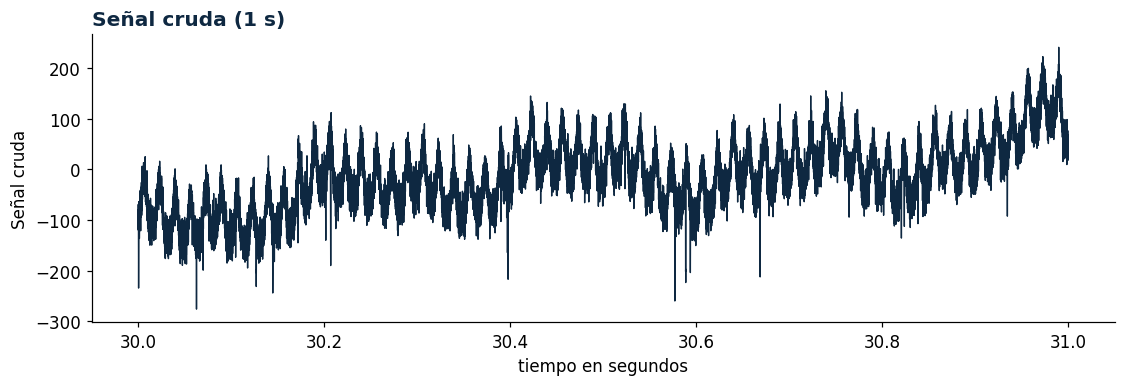

In [40]:
def ver(x, titulo, t0, t1, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    # Su código aquí: máscara de la ventana, plot, título y ejes CON UNIDADES
    m = (t >= t0) & (t < t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("tiempo en segundos")                          # no olvides las unidades
    plt.ylabel("Señal cruda")
ver(cruda, "Señal cruda (1 s)", 30.0, 31.0)



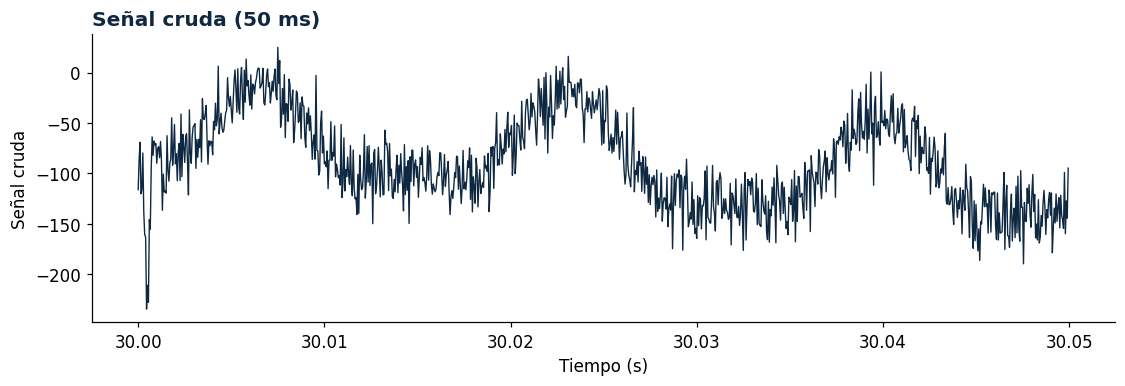

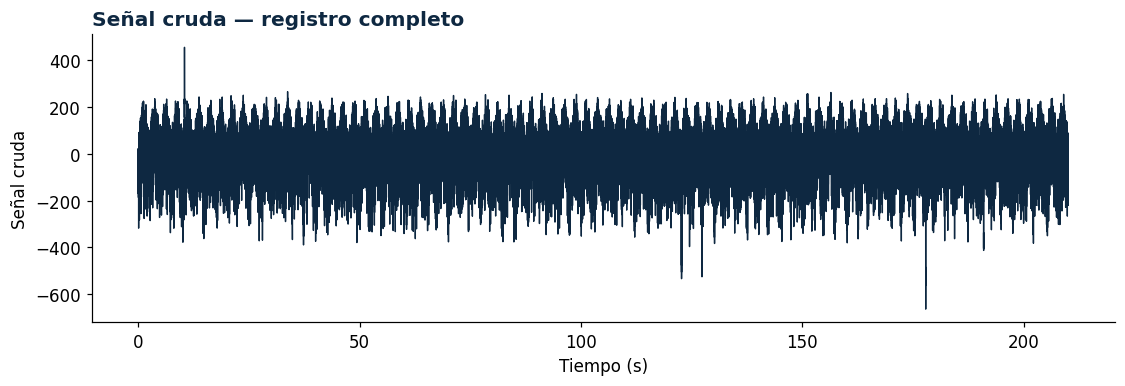

In [41]:
# Su código aquí: los otros dos zooms (50 ms y el registro completo).

def ver_50ms(x, titulo, t0, inicio_ms, color=NAVY):
    """Grafica una ventana de 50 ms dentro del segundo que comienza en t0."""
    # Convertimos milisegundos a segundos
    inicio = t0 + inicio_ms / 1000
    fin = inicio + 0.050
    # Máscara para seleccionar solamente los 50 ms
    m = (t >= inicio) & (t < fin)
    # Crear gráfica
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Señal cruda")
ver_50ms(cruda, "Señal cruda (50 ms)", t0=30.0, inicio_ms=0)

def ver_cruda(x, titulo,  color=NAVY):
    """Grafica la señal cruda en el registro completo"""
    plt.figure()
    plt.plot(t, x, color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")                          # no olvides las unidades
    plt.ylabel("Señal cruda")
ver_cruda(cruda, "Señal cruda — registro completo")


**Los tres problemas que encontramos:**

1. Deriva lenta de la linea base (LFP) el cual se ve en el fragmento de 1 s y 50 ms, pues la señal sube y baja lentamente formando una onda grande lo cual corresponde a un cambio gradual del voltaje
2. Oscilacion periodica de 60 Hz y se ve principalmente en el registro completo, pues es un patron repetitivo dentro del ensayo e irregular que indica una frecuencia fija
3. Artefactos de gran amplitud los cuales son picos mucho mas grandes que el resto de la señal y ocurren de forma esporadica en todas las graficas

**Pregunta B2.** ¿Cuál de los tres nos impide contar los disparos a ojo, como hicimos
en la Sesión 3?

> Porque los spikes también son eventos rápidos. La oscilación de 60 Hz llena toda la señal de pequeñas variaciones y hace difícil distinguir visualmente cuáles picos son verdaderos potenciales de acción y cuáles pertenecen al ruido eléctrico.

---
## C · Diagnosticar el ruido: el espectro de potencia

Mirar la señal en el tiempo les dice que *hay* algo raro. El **espectro de potencia** les
dice **qué** es: cuánta energía tiene la señal en cada frecuencia. Es la herramienta de
diagnóstico, y se mira **antes** de filtrar nada, porque un filtro que no hacía falta
también deforma la señal.

Qué van a buscar en él:

| En el espectro | Qué es |
|---|---|
| un **pico angosto** en una frecuencia exacta | algo instrumental: la red eléctrica |
| energía en las **frecuencias muy bajas** (< 5 Hz) | la deriva lenta |
| energía entre **300 y 3000 Hz** | los potenciales de acción |
| un **piso plano** que nunca baja | ruido térmico, presente en todas las frecuencias |

### ✍️ Ejercicio C1 · Escriban su prompt
Necesitan una función `espectro()`. En la Sesión 4 vimos **para qué** sirve el espectro y
qué se busca en él; programarlo es de hoy. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `fs` (frecuencia de muestreo), `etiqueta` (título), `fmax=500` |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch` y `nperseg=8192`; graficar solo hasta `fmax`, con el eje y en escala logarítmica (`plt.semilogy`), ejes rotulados con unidades |

Antes de escribirlo, repasen los **5 elementos**. Un prompt que solo diga *"hazme un
espectro"* devuelve algo que no encaja con estos datos.

_Escriban aquí su prompt:_

>De acuerdo a lo visto en este chat y otros anteriores, me puedes ayudar a escribir una funcion q nos permita ver cuanta energia tiene la señal en cada frecuencia para asi poder buscar lo que se pide en la tabla a continuacion:

| En el espectro | Qué es |
|---|---|
| un **pico angosto** en una frecuencia exacta | algo instrumental: la red eléctrica |
| energía en las **frecuencias muy bajas** (< 5 Hz) | la deriva lenta |
| energía entre **300 y 3000 Hz** | los potenciales de acción |
| un **piso plano** que nunca baja | ruido térmico, presente en todas las frecuencias |

>con las especificaciones que se muestran en la siguiente tabla:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `fs` (frecuencia de muestreo), `etiqueta` (título), `fmax=500` |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch` y `nperseg=8192`; graficar solo hasta `fmax`, con el eje y en escala logarítmica (`plt.semilogy`), ejes rotulados con unidades |

>explicame cada parte de este codigo por favor

>

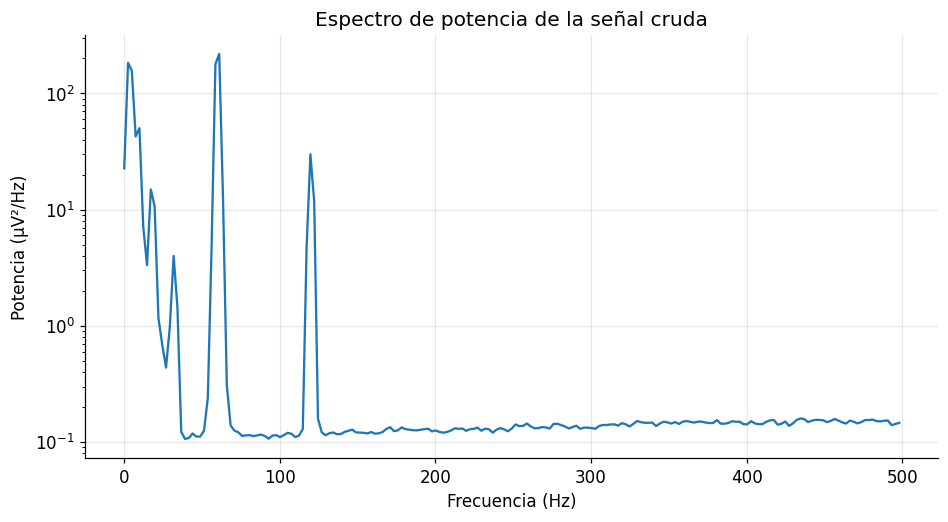

Pico dominante entre 40 y 200 Hz: 61.0 Hz


In [42]:
# Su código aquí: peguen o escriban espectro() y aplíquenla a la señal cruda.
# Al final tienen que quedar definidas estas dos variables:
def espectro(x, fs, etiqueta, fmax=500):
    # Calcular el espectro de potencia usando Welch
    f, P = welch(x, fs=fs, nperseg=8192)
    # Seleccionar solamente las frecuencias hasta fmax
    m = f <= fmax
    # Graficar potencia contra frecuencia en escala logarítmica
    plt.figure(figsize=(10, 5))
    plt.semilogy(f[m], P[m])
    # Rotular los ejes con sus unidades
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Potencia (µV²/Hz)")
    plt.title(etiqueta)
    # Mostrar una cuadrícula para facilitar la lectura
    plt.grid(alpha=0.3)
    plt.show()
    # Devolver las frecuencias y sus potencias
    return f, P
f, P = espectro(cruda, fs, "Espectro de potencia de la señal cruda")      # llamen a su función aquí
# Esta línea dice cuál es la frecuencia con más potencia entre 40 y 200 Hz:
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])
print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")

In [43]:
# ✅ VERIFICACIÓN · ejercicio C1
revisar("espectro() devuelve dos arrays del mismo tamaño",
        len(f) == len(P) and len(f) > 100,
        "welch devuelve (frecuencias, potencias): hay que retornar las dos")
revisar("las frecuencias llegan hasta Nyquist (10 000 Hz)",
        f.max() > 9000,
        "grafiquen solo hasta fmax, pero calculen el espectro completo")
revisar("el pico dominante está en la red eléctrica (~60 Hz)",
        55 < pico < 65,
        "revisen que le pasaron fs a welch y no el valor por defecto")
revisar("la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)",
        pot(cruda, 55, 65, fs) > 2 * pot(cruda, 5, 15, fs))
revisar("hay energía en la banda de los potenciales de acción",
        pot(cruda, 300, 3000, fs) > 0)

  OK    espectro() devuelve dos arrays del mismo tamaño
  OK    las frecuencias llegan hasta Nyquist (10 000 Hz)
  OK    el pico dominante está en la red eléctrica (~60 Hz)
  OK    la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)
  OK    hay energía en la banda de los potenciales de acción


**Pregunta C2.** Con números, no de memoria:

- El pico no cae exactamente en 60,0 Hz. Miren cuánto vale `f[1] - f[0]`: esa es la
  **resolución** de su espectro. ¿Explica la diferencia?
- Hay otro pico más pequeño al doble de 60 Hz. ¿Cómo se llama y de dónde sale?
- La deriva lenta (0.4 Hz) se ve clarísima en la señal. ¿Aparece como un pico en el espectro? Miren
  cuánto dura un segmento de Welch (`nperseg / fs`, en segundos) y compárenlo con el
  período de la deriva (1/0,4 Hz = 2,5 s). ¿Cabe siquiera un ciclo dentro del segmento?
  Repitan el espectro con `nperseg = 200000` y miren qué aparece por debajo de 1 Hz.
  ¿Qué se dañó a cambio?
- ¿Por qué el eje y va en escala logarítmica? Vuelvan a graficar con `plt.plot` en vez de
  `plt.semilogy` y digan qué dejan de ver.

_Escriban su respuesta aquí:_


1. El pico aparece en 61.0 Hz porque la resolución del espectro es aproximadamente \(f[1]-f[0]\approx2.44\) Hz. Por ello, Welch no evalúa exactamente 60 Hz y el punto disponible más cercano es aproximadamente 61.0 Hz.

2. El pico cercano a 120 Hz es el segundo armónico de la interferencia de 60 Hz, ya que corresponde a \(2\times60=120\) Hz.

3. Con nperseg=8192, cada segmento dura \(8192/20000=0.4096\) s. La deriva de 0.4 Hz tiene un período de 2.5 s, por lo que solo caben \(0.4096/2.5\approx0.164\) ciclos en cada segmento. Por eso no aparece claramente como un pico.

4. Con nperseg=200000, el segmento dura 10 s y contiene 4 ciclos de la deriva. Además, la resolución mejora a 0.1 Hz, por lo que aparece el pico alrededor de 0.4 Hz. A cambio, hay menos segmentos para promediar y la estimación de Welch se vuelve menos estable.

5. Se usa escala logarítmica en Y porque la potencia puede variar mucho entre frecuencias. Con plt.plot, los componentes de baja potencia quedan comprimidos cerca de cero y se pierde visibilidad del piso de ruido y de otras componentes débiles.

## D · Filtrar (una sola vez, dos bandas)

La señal es una **mezcla** de cosas que ocurren a velocidades distintas:

| Componente | Qué es | Banda |
|---|---|---|
| **Deriva** | movimiento, cambios de temperatura, electroquímica del electrodo | < 5 Hz |
| **LFP** | corrientes sinápticas sumadas de muchas neuronas | < 300 Hz |
| **60 Hz** | red eléctrica, y su armónico en 120 Hz | 60 y 120 Hz |
| **Potenciales de acción** | los disparos de las neuronas cercanas | 300 a 5000 Hz |
| **Ruido térmico** | agitación de los electrones en el electrodo y la electrónica | todas |

Cortar en 300 Hz es una convención del oficio, no una ley de la naturaleza: en la
pregunta D4 van a ver qué tan arbitraria es.


### ✍️ Ejercicio D1 · Escriban su prompt

>Necesitan **una sola** función de filtrado que sirva para los dos casos. También es nueva:
en la Sesión 4 vimos qué le hace un filtro a una señal, no cómo se escribe.

| | |
|---|---|
| **Entradas** | `x` (señal), `fs`, `baja=None` (corte inferior), `alta=None` (corte superior), `orden=3` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `alta`, es pasa-bajos; si solo se da `baja`, es pasa-altos; si se dan las dos, pasa-banda |
| **Exigencias** | fase cero (`filtfilt` o `sosfiltfilt`) y frecuencias normalizadas por Nyquist |

La **fase cero** no es un capricho: un filtro normal retrasa la señal, y el retraso depende
de la frecuencia. Si filtran así, los disparos se les mueven en el tiempo y todo lo que
midan después queda corrido — y las figuras van a salir igual de creíbles.


_Escriban aquí su prompt:_

necesito una sola funcion de filtrado que sirva como pasa-bajos, pasa-altos o pasa-banda dependiendo de qué argumentos le entreguen. con las siguientes caracteristicas

| | |
|---|---|
| **Entradas** | `x` (señal), `fs`, `baja=None` (corte inferior), `alta=None` (corte superior), `orden=3` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `alta`, es pasa-bajos; si solo se da `baja`, es pasa-altos; si se dan las dos, pasa-banda |
| **Exigencias** | fase cero (`filtfilt` o `sosfiltfilt`) y frecuencias normalizadas por Nyquist |

>

<Figure size 1320x374 with 0 Axes>

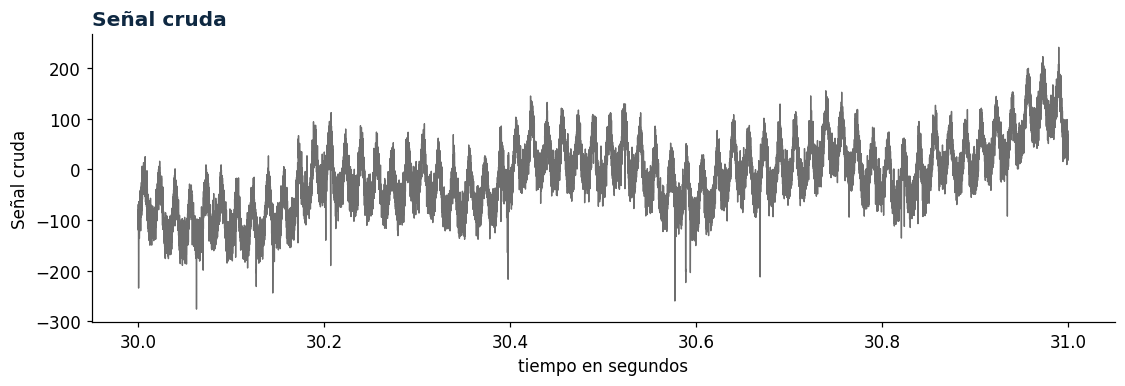

<Figure size 1320x374 with 0 Axes>

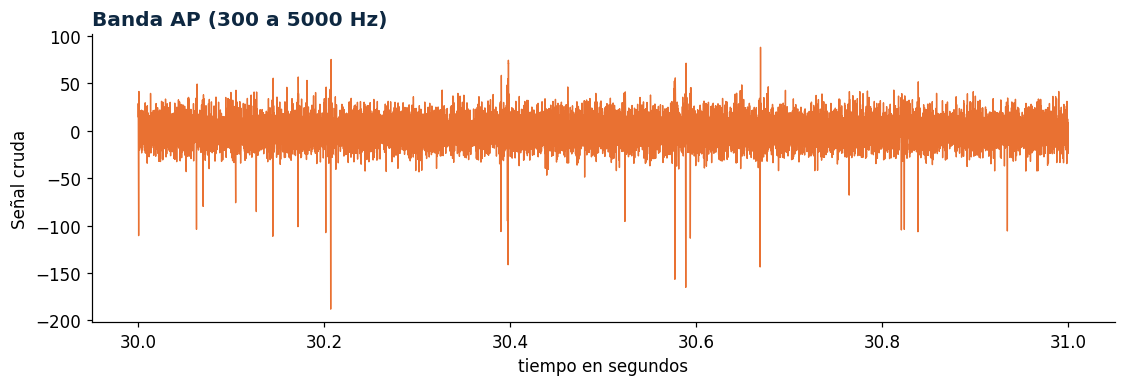

In [44]:
# Su código aquí: la función filtrar(), y con ella la banda de los potenciales de acción.
from scipy.signal import butter, sosfiltfilt
def filtrar(x, fs, baja=None, alta=None, orden=3):
    # Frecuencia de Nyquist
    nyquist = fs / 2
    # Comprobar que se haya dado al menos una frecuencia de corte
    if baja is None and alta is None:
        raise ValueError("Debes especificar baja, alta o ambas.")
    # Caso 1: pasa-bajos
    if baja is None:
        wn = alta / nyquist
        sos = butter(orden,wn,btype="lowpass",output="sos")
    # Caso 2: pasa-altos
    elif alta is None:
        wn = baja / nyquist
        sos = butter(orden,wn,btype="highpass",output="sos")
    # Caso 3: pasa-banda
    else:
        wn = [baja / nyquist, alta / nyquist]
        sos = butter(orden,wn,btype="bandpass",output="sos")
    # Aplicar el filtro hacia adelante y hacia atrás
    # para obtener fase cero
    y = sosfiltfilt(sos, x)
    return y
AP = filtrar(cruda, fs, baja=300, alta=5000)      # pasa-banda de 300 a 5000 Hz sobre la señal cruda
plt.figure(); ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.0, t1=31.0, color=ORANGE)

In [45]:
# ✅ VERIFICACIÓN · ejercicio D1
print(f"sigma robusta   ·   cruda: {np.median(np.abs(cruda))/0.6745:6.1f} µV"
      f"   ·   AP: {np.median(np.abs(AP))/0.6745:6.1f} µV")
print(f"potencia en 60 Hz   ·   cruda: {pot(cruda,55,65,fs):9.1f}"
      f"   ·   AP: {pot(AP,55,65,fs):9.4f}\n")

revisar("la banda AP tiene el mismo tamaño que la señal original",
        len(AP) == len(cruda), "filtfilt devuelve una señal de la misma longitud")
revisar("la banda AP botó la deriva y el LFP",
        pot(AP, 0, 50, fs) < 0.001 * pot(cruda, 0, 50, fs),
        "si sobrevive lo lento, el filtro quedó como pasa-bajos")
revisar("la banda AP botó el ruido de red de 60 Hz",
        pot(AP, 55, 65, fs) < 0.001 * pot(cruda, 55, 65, fs))
revisar("la banda AP conservó los potenciales de acción (300-3000 Hz)",
        pot(AP, 300, 3000, fs) > 0.5 * pot(cruda, 300, 3000, fs))
revisar("el ruido de la banda AP es mucho menor que el de la señal cruda",
        np.median(np.abs(AP))/0.6745 < 0.4 * (np.median(np.abs(cruda))/0.6745))

sigma robusta   ·   cruda:   70.8 µV   ·   AP:   13.5 µV
potencia en 60 Hz   ·   cruda:     413.8   ·   AP:    0.0000

  OK    la banda AP tiene el mismo tamaño que la señal original
  OK    la banda AP botó la deriva y el LFP
  OK    la banda AP botó el ruido de red de 60 Hz
  OK    la banda AP conservó los potenciales de acción (300-3000 Hz)
  OK    el ruido de la banda AP es mucho menor que el de la señal cruda


**Pregunta D2**

En la Sesión vimos que un filtro **notch** sirve para eliminar frecuencias específicas, como la de 60 Hz. Aquí no hizo falta ninguno y la
verificación acaba de decirles que la banda AP ya no tiene nada en 60 Hz.

- Miren en qué banda está el ruido de red y en qué banda están los disparos, y expliquen en
  dos líneas **por qué el pasa-banda hace el trabajo del notch** en este caso.
- ¿Qué le pasó a la deriva? ¿Y a los artefactos enormes que encontraron en la sección B?
- Entonces, ¿**cuándo** sí haría falta un notch? (Piensen qué quieren conservar.)

_Escriban su respuesta aquí:_

>El pasa-banda de 300–5000 Hz elimina el ruido de red de 60 y 120 Hz porque estas frecuencias están por debajo de 300 Hz, mientras que conserva la banda donde se encuentran los potenciales de acción. La deriva (<5 Hz) y los componentes lentos de los artefactos grandes también fueron atenuados, aunque los artefactos con componentes entre 300 y 5000 Hz pueden permanecer. Un notch sí sería necesario cuando queremos conservar las frecuencias bajas, como en un análisis de LFP, pero necesitamos eliminar específicamente la interferencia de 60 Hz.


### 📋 Ejercicio D3 · La otra banda: LFP, y ahí sí el notch

La respuesta a la última pregunta es: cuando lo que quieren conservar es **lo lento**. La
banda LFP vive por debajo de 300 Hz, y los 60 Hz están justo en medio: un pasa-bajos no los
puede quitar sin llevarse la señal biológica. Para eso está el *notch*, que elimina una
franja **muy angosta** y deja el resto casi intacto.

Copien este prompt **tal cual** en ChatGPT o Claude. Lean la respuesta completa antes de
usarla:

> Trabajo en Python con numpy y scipy. Tengo un array `cruda` con el voltaje (en µV) de un
> registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en
> 60 Hz y su armónico en 120 Hz. Escríbeme una función `notch(x, f0, fs, Q=30)` que use
> `scipy.signal.iirnotch` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo.
> Explícame qué controla el parámetro `Q` y por qué en electrofisiología se usa `filtfilt`
> y no `lfilter`. Rotula todo con unidades y explícame cada línea.

Antes de correr nada, contesten: **¿el código que les dio sirve, o le sobra o le falta
algo?** Fíjense sobre todo en si le pasa la frecuencia de muestreo al diseñar el filtro:
es el error más común.

Después obtengan la banda LFP: quiten 60 y 120 Hz con el notch, y **luego** apliquen su
`filtrar()` como pasa-bajos de 300 Hz.

<Figure size 1320x374 with 0 Axes>

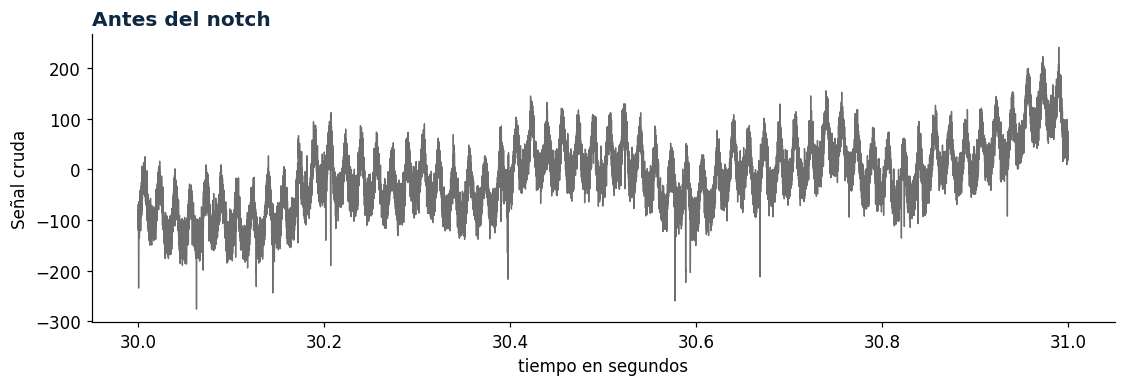

<Figure size 1320x374 with 0 Axes>

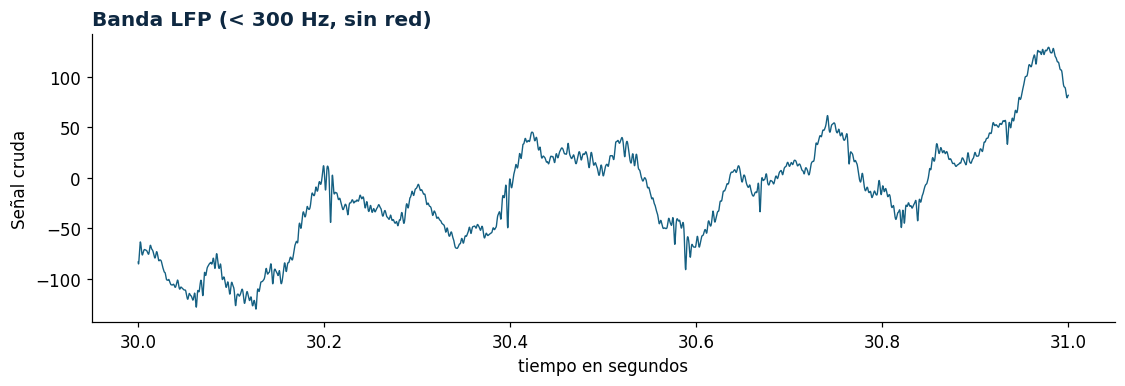

In [46]:
# Peguen aquí la función notch() (la de la IA, corregida por ustedes) y obtengan el LFP.
# Ojo: son DOS frecuencias, 60 y 120 Hz.
from scipy.signal import iirnotch, filtfilt
def notch(x, f0, fs, Q=30):
    # Diseñar el filtro notch para la frecuencia f0
    b, a = iirnotch(f0, Q, fs)
    # Aplicar el filtro hacia adelante y hacia atrás
    y = filtfilt(b, a, x)
    # Devolver la señal filtrada
    return y
sin_red = notch(cruda, 60, fs)
sin_red = notch(sin_red, 120, fs)
LFP = filtrar(sin_red, fs, alta=300)
#sin_red = ____            # la señal cruda sin ruido de red
#LFP     = ____            # pasa-bajos de 300 Hz sobre sin_red
plt.figure(); ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(LFP,   "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)

<Figure size 1320x374 with 0 Axes>

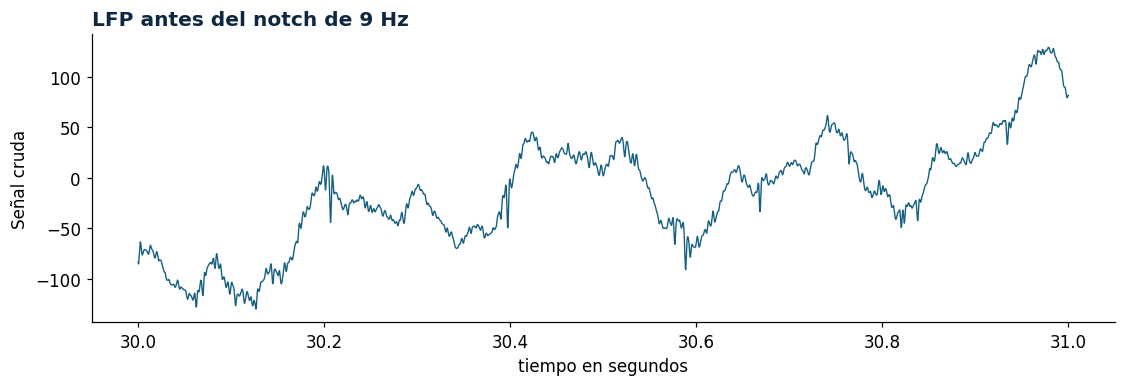

<Figure size 1320x374 with 0 Axes>

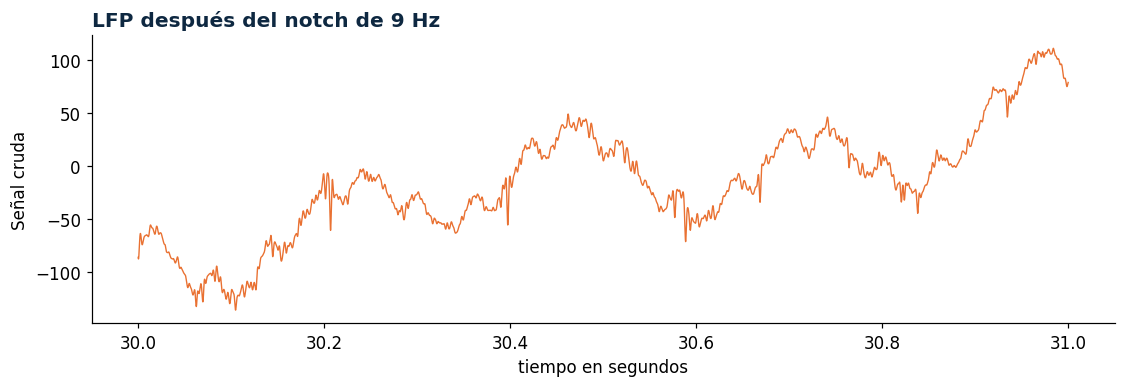

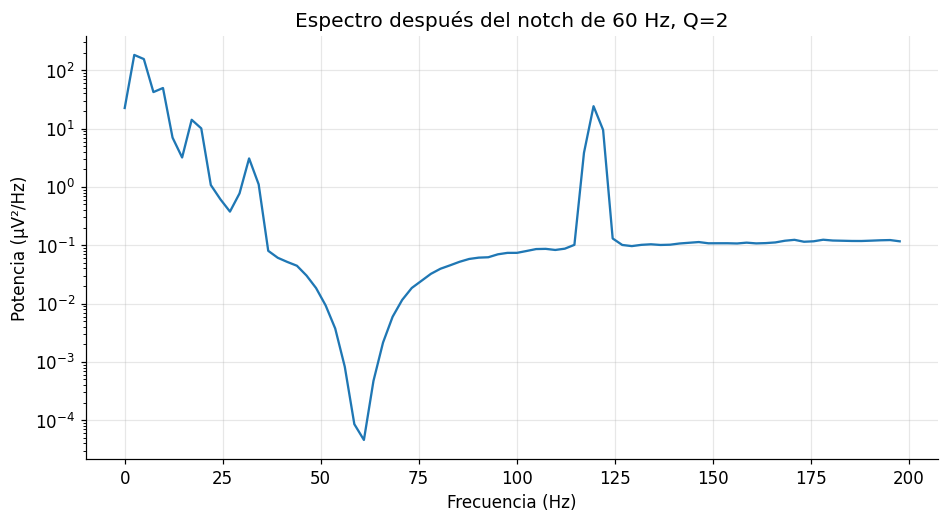

<Figure size 1320x374 with 0 Axes>

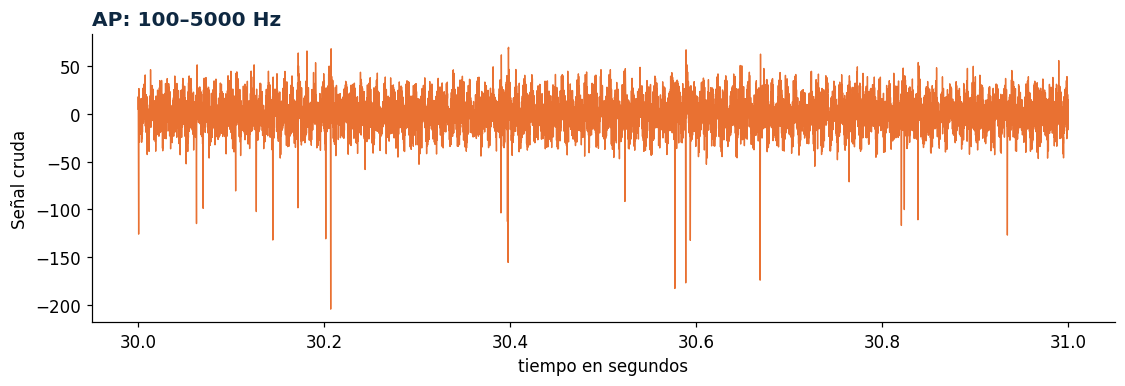

<Figure size 1320x374 with 0 Axes>

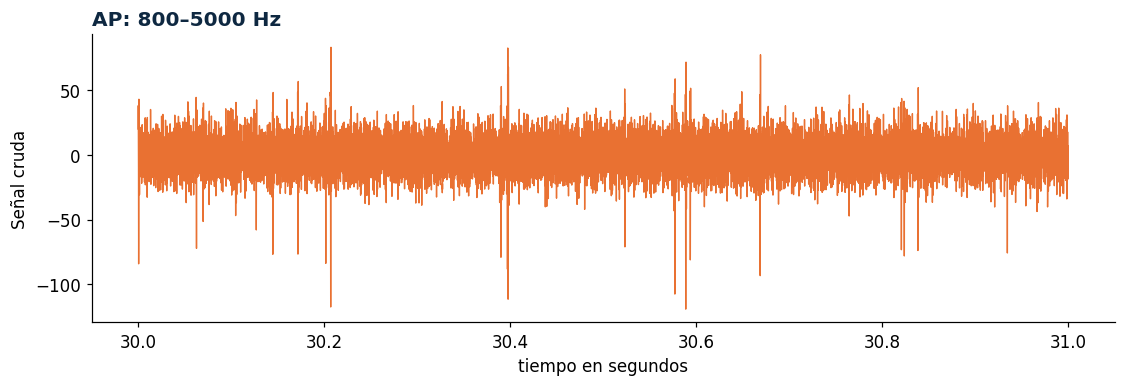

In [47]:
#PRUEBA NOTCH DE 9 Hz
LFP_9Hz = notch(LFP, 9, fs)
plt.figure()
ver(LFP, "LFP antes del notch de 9 Hz",
    t0=30.0, t1=31.0, color=TEAL)
plt.figure()
ver(LFP_9Hz, "LFP después del notch de 9 Hz",
    t0=30.0, t1=31.0, color=ORANGE)
sin_60_Q2 = notch(cruda, 60, fs, Q=2)
f_Q2, P_Q2 = espectro(
    sin_60_Q2,
    fs,
    "Espectro después del notch de 60 Hz, Q=2",
    fmax=200
)
AP_100 = filtrar(
    cruda,
    fs,
    baja=100,
    alta=5000
)
AP_800 = filtrar(
    cruda,
    fs,
    baja=800,
    alta=5000
)
plt.figure()
ver(AP_100, "AP: 100–5000 Hz",
    t0=30.0, t1=31.0, color=ORANGE)
plt.figure()
ver(AP_800, "AP: 800–5000 Hz",
    t0=30.0, t1=31.0, color=ORANGE)

In [48]:
# ✅ VERIFICACIÓN · ejercicio D3
caida_60  = 10*np.log10(pot(cruda,  55,  65, fs) / pot(sin_red,  55,  65, fs))
caida_120 = 10*np.log10(pot(cruda, 115, 125, fs) / pot(sin_red, 115, 125, fs))
cambio_lento = abs(10*np.log10(pot(cruda, 5, 15, fs) / pot(sin_red, 5, 15, fs)))
print(f"caída en 60 Hz: {caida_60:.1f} dB   ·   en 120 Hz: {caida_120:.1f} dB")
print(f"cambio en la banda del LFP (5-15 Hz): {cambio_lento:.2f} dB\n")

revisar("el notch bajó los 60 Hz al menos 10 dB", caida_60 > 10,
        "revisen que le pasaron fs=20000 a iirnotch")
revisar("también quitaron el armónico de 120 Hz", caida_120 > 10,
        "hay que aplicar el notch dos veces, una por cada frecuencia")
revisar("el notch NO tocó la banda del LFP", cambio_lento < 1.0,
        "si el LFP también cayó, la Q es demasiado baja: el notch quedó muy ancho")
revisar("el LFP es mucho más grande que la banda AP",
        LFP.std() > 3 * AP.std(),
        "en un registro extracelular casi toda la varianza está en lo lento")

caída en 60 Hz: 31.6 dB   ·   en 120 Hz: 24.1 dB
cambio en la banda del LFP (5-15 Hz): 0.00 dB

  OK    el notch bajó los 60 Hz al menos 10 dB
  OK    también quitaron el armónico de 120 Hz
  OK    el notch NO tocó la banda del LFP
  OK    el LFP es mucho más grande que la banda AP


**Pregunta D4.** Dos experimentos cortos y una conclusión:

- Apliquen un notch en **9 Hz**, donde sí hay señal biológica. Grafiquen antes y después y
  digan qué le pasó al LFP.
- Vuelvan al notch de 60 Hz pero con `Q = 2`. ¿Qué controla Q? Grafiquen el espectro
  resultante: ¿qué se llevó por delante?
- Repitan el pasa-banda de la banda AP moviendo el corte inferior a **100 Hz** y a
  **800 Hz**. ¿Qué se cuela con 100 Hz? ¿Qué le pasa a la **forma** de los disparos con
  800 Hz? Si tuvieran que justificar el corte de 300 Hz en un artículo, ¿qué dirían?

Con eso, contesten en una línea: **¿por qué el diagnóstico va antes del filtrado?**

_Escriban su respuesta aquí:_

1. El notch de 9 Hz eliminó una componente del LFP que sí podía corresponder a actividad biológica, por lo que se perdió información de la señal alrededor de esa frecuencia.

2. Q controla el ancho de banda del notch. Con Q=2, el notch es mucho más ancho y elimina no solo la interferencia de 60 Hz, sino también componentes de frecuencias cercanas, pudiendo eliminar parte de la señal biológica.

3. Con un corte inferior de 100 Hz se cuelan más componentes de baja frecuencia pertenecientes al LFP y algunos artefactos, porque estamos incluyendo una región que antes eliminábamos al cortar en 300 Hz.
Con un corte inferior de 800 Hz se elimina parte del contenido frecuencial de los potenciales de acción, por lo que cambia su morfología: pueden verse más estrechos, con menor amplitud o con una forma diferente. Si quiero ser riguroso puedo decir que "El corte de 300 Hz se seleccionó como una convención operacional basada en el contenido espectral observado en el registro, no como una frontera biológica absoluta entre LFP y potenciales de acción."

En una linea:

Primero se diagnostica para saber qué queremos eliminar y qué debemos conservar; después se filtra para no borrar información biológica.

---
## E · Detectar los disparos · **el ejercicio central**

### ✏️ Ejercicio E1 · El detector

Escriban una función que reciba la señal filtrada y devuelva los índices de las muestras
donde hay un potencial de acción.

**La especificación es esta y no la pueden cambiar:**

```
detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) -> np.ndarray de índices enteros
```

| | |
|---|---|
| `x` | señal **filtrada**, en µV |
| `fs` | frecuencia de muestreo, en Hz |
| `k` | cuántas veces el nivel de ruido se pone el umbral |
| `muerto_ms` | tiempo mínimo entre dos detecciones consecutivas |
| **devuelve** | los índices de las muestras donde ocurre cada disparo, ordenados y sin repetir |

**Cuatro decisiones que la función tiene que resolver.** Están enunciadas como preguntas a
propósito: si le piden a la IA "escribe un detector de spikes", casi seguro se equivocará
en al menos dos de ellas.

1. **¿Hacia dónde apunta un potencial de acción extracelular?** Miren un evento de cerca
   antes de decidir.
2. **¿Cómo se fija el umbral?** Un valor fijo en microvoltios no sirve. Hay que medir el
   ruido y poner el umbral en `k` veces esa medida. Y ojo con la trampa: la desviación
   estándar está inflada por los propios disparos. Busquen **MAD** (*median absolute
   deviation*) y por qué se divide por 0,6745:

   $$\hat{\sigma} = \frac{\text{mediana}(|x|)}{0{,}6745}, \qquad \text{umbral} = -k\,\hat{\sigma}$$

3. **Un disparo cruza el umbral durante varias muestras seguidas.** Si marcan cada muestra
   que cruza, cuentan el mismo evento muchas veces. Hay que agrupar las muestras contiguas
   y quedarse con **una** por evento. ¿Con cuál?
4. **El período muerto.** Después de marcar un evento hay que saltar `muerto_ms` hacia
   adelante. El valor por defecto, 1,5 ms, viene del período refractario de una neurona.
   En la sección F van a descubrir por qué aquí eso es discutible.

In [49]:
def detectar_spikes(x, fs, k=4.5, muerto_ms=1.0):
    """Devuelve los índices de las muestras donde hay un potencial de acción."""
    # 1. Estimar el nivel de ruido usando MAD
    sigma = np.median(np.abs(x)) / 0.6745
    # 2. Definir un umbral negativo
    umbral = -k * sigma
    # 3. Encontrar las muestras que cruzan el umbral
    cruza = x < umbral
    # 4. Encontrar el inicio y final de cada grupo de muestras contiguas
    cambios = np.diff(cruza.astype(int))
    inicios = np.where(cambios == 1)[0] + 1
    finales = np.where(cambios == -1)[0]
    # Caso en que el primer grupo comienza en la muestra 0
    if cruza[0]:
        inicios = np.insert(inicios, 0, 0)
    # Caso en que el último grupo llega hasta el final
    if cruza[-1]:
        finales = np.append(finales, len(x) - 1)
    # 5. De cada evento, quedarse con la muestra de máxima negatividad
    candidatos = np.array([
        inicio + np.argmin(x[inicio:final + 1])
        for inicio, final in zip(inicios, finales)
    ], dtype=int)
    # 6. Aplicar el período muerto
    muerto_muestras = int(muerto_ms * fs / 1000)
    indices = []
    for idx in candidatos:
        if len(indices) == 0:
            indices.append(idx)
        elif idx - indices[-1] >= muerto_muestras:
            indices.append(idx)
    return np.array(indices, dtype=int)
indices = detectar_spikes(AP, fs)
tiempos = indices / fs                    # índices -> segundos
sigma   = np.median(np.abs(AP)) / 0.6745
umbral  = -4.5 * sigma
print(f"sigma del ruido ≈ {sigma:.1f} µV   ·   umbral = {umbral:.1f} µV")
print(f"detectados: {len(indices)} disparos en {len(AP)/fs:.0f} s "
      f"({len(indices)/(len(AP)/fs):.1f} por segundo)")

sigma del ruido ≈ 13.5 µV   ·   umbral = -60.9 µV
detectados: 5496 disparos en 210 s (26.2 por segundo)


In [50]:
# ✅ VERIFICACIÓN · ejercicio E1
indices = np.asarray(indices)
revisar("detectar_spikes() devuelve índices enteros, no tiempos",
        indices.dtype.kind in "iu" and indices.max() < len(AP),
        "los índices son posiciones en el array; los tiempos salen después, con indices/fs")
revisar("el número de detecciones es plausible (entre 4000 y 7000)",
        4000 <= len(indices) <= 7000,
        "si salen decenas de miles, no están agrupando los cruces; si salen cientos, el umbral es muy exigente")
revisar("todos los índices caen por debajo del umbral",
        bool(np.all(AP[indices] < umbral)),
        "están guardando el índice del cruce o del final de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(indices) >= 0.001*fs - 1)),
        "después de marcar un evento hay que saltar muerto_ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(indices) > 0)))

  OK    detectar_spikes() devuelve índices enteros, no tiempos
  OK    el número de detecciones es plausible (entre 4000 y 7000)
  OK    todos los índices caen por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


### ✏️ Ejercicio E2 · La figura de control

Una figura que muestre el resultado: la banda AP, la línea del umbral y un marcador sobre
el pico de cada disparo detectado, en una ventana de **200 ms**.

Fíjense en la línea de `d`: selecciona solo las detecciones que caen dentro de la ventana
que están graficando. Sin eso, matplotlib intenta dibujar marcadores fuera del eje y la
figura queda comprimida.

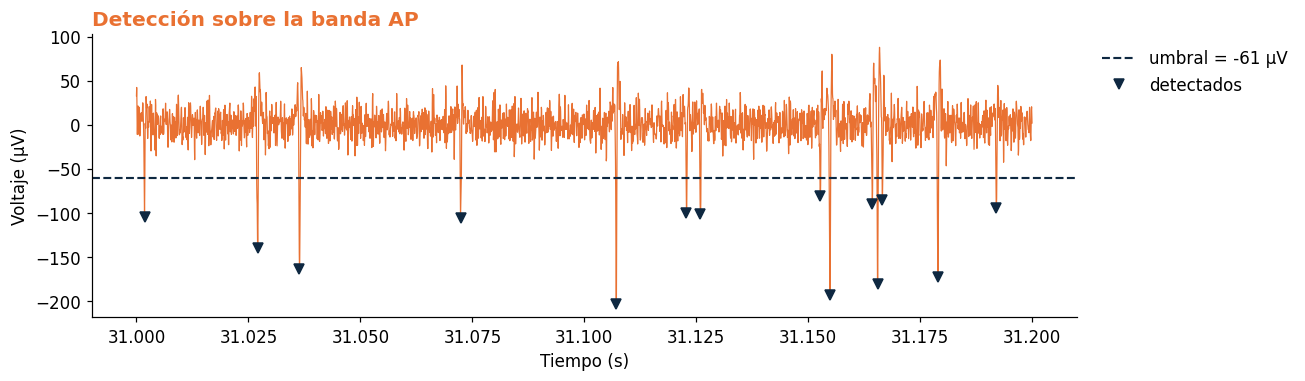

In [51]:
t0, t1 = 31.0, 31.2
m = (t >= t0) & (t < t1)
d = indices[(tiempos >= t0) & (tiempos < t1)]      # detecciones dentro de la ventana

plt.figure(figsize=(12, 3.6))
plt.plot(t[m], AP[m], color=ORANGE, lw=0.8)
plt.axhline(umbral, color=NAVY, ls="--", lw=1.4, label=f"umbral = {umbral:.0f} µV")
plt.plot(d / fs, AP[d], "v", color=NAVY, ms=7, ls="none", label="detectados")  # ¿tiempo y voltaje de qué?
plt.xlabel("Tiempo (s)"); plt.ylabel("Voltaje (µV)")
plt.title("Detección sobre la banda AP", color=ORANGE, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()



✅ **Revisen la figura a ojo:**

- [ ] Los triángulos caen **encima** del pico de cada evento, no flotando ni desplazados.
- [ ] No hay ningún disparo evidente sin su triángulo.
- [ ] No hay triángulos sobre puntos que claramente son ruido.
- [ ] Hay leyenda y los ejes tienen unidades.

Si algo falla, arreglen la función antes de seguir: todo lo que viene la usa.


ANOTACION:

>El spike de −181.3 µV no se detectaba inicialmente porque estaba separado solo 1.20 ms del evento anterior y 1.05 ms del siguiente, ambos intervalos menores al período muerto de 1.5 ms. Al reducir temporalmente el período muerto a 1.0 ms, el spike fue detectado, demostrando que no era un problema del umbral sino del período muerto. Sin embargo, reducirlo demasiado puede producir detecciones múltiples de un mismo evento.

>Por esta razon se decicio usar el tiempo de 1.5 ms en los siguientes jercicios de ser necesario, pues se conocen los riesgos de disminuir el tiempo muerto.

---
## F · ¿Le acertamos?

Su detector devolvió miles de instantes. Hasta aquí no saben si son buenos: *"detecté
5 400 disparos"* no dice nada por sí solo. **La pregunta es cuáles.**

### Los tres números

| | |
|---|---|
| **VP** verdadero positivo | detectaron algo y ahí había un disparo de verdad |
| **FP** falso positivo | detectaron algo donde no había nada: ruido que cruzó el umbral |
| **FN** falso negativo | había un disparo y no lo detectaron |

De ahí salen las dos medidas que van a reportar:

$$\text{precisión} = \frac{VP}{VP + FP} \qquad\qquad \text{exhaustividad} = \frac{VP}{VP + FN}$$

**Precisión** responde *de lo que detecté, ¿cuánto es real?* (si es baja, están inventando
disparos). **Exhaustividad** responde *de lo que había, ¿cuánto encontré?* (si es baja, se
les están escapando). Las dos se mueven en direcciones opuestas cuando mueven el umbral, y
ahí está toda la gracia del ejercicio F2.

### Dos detalles que casi nadie acierta a la primera

**1. La tolerancia.** Su detector no marca el evento en el instante exacto: devuelve el
instante del mínimo, que llega una fracción de milisegundo después del inicio real. Es un
desfase sistemático, no un error. Por eso no se puede exigir coincidencia exacta: hay que
fijar una **ventana de tolerancia** (aquí, 1 ms) dentro de la cual dos marcas cuentan como
la misma.

**2. No reutilizar.** Cada disparo real puede emparejarse con **una sola** detección. Si no
lo imponen, dos detecciones sobre el mismo evento cuentan las dos como aciertos y su
precisión sale inflada.

### ✍️ Ejercicio F1 · Escriban su prompt

```
emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)
```

Los tiempos vienen ordenados. Escríbanla ustedes con ayuda del modelo, y **especifiquen
las dos reglas de arriba en el prompt**: si no lo hacen, el código que les devuelva va a
contar mal y va a correr perfectamente.

_Escriban aquí su prompt:_

>Habiendote explicado los VP, FP, FN, las ecuaciones de precision y exhaustividad, la tolerancia y no reutilizar, escribe una funcion que cumpla con las siguientes condiciones: emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN). explicame cada parte de este codigo.

In [52]:
def emparejar(detectados_s, reales_s, tol_ms=1.0):
    # Convertir la tolerancia de milisegundos a segundos
    tol_s = tol_ms / 1000
    # Asegurar que sean arreglos ordenados
    detectados_s = np.asarray(detectados_s)
    reales_s = np.asarray(reales_s)
    i = 0  # índice de detecciones
    j = 0  # índice de tiempos reales
    VP = 0
    FP = 0
    FN = 0
    while i < len(detectados_s) and j < len(reales_s):
        diferencia = detectados_s[i] - reales_s[j]
        # La detección coincide con el disparo real
        if abs(diferencia) <= tol_s:
            VP += 1
            i += 1
            j += 1
        # La detección está antes que el real
        elif detectados_s[i] < reales_s[j]:
            FP += 1
            i += 1
        # El real está antes que la detección
        else:
            FN += 1
            j += 1
    # Detecciones que quedaron sin emparejar
    FP += len(detectados_s) - i
    # Disparos reales que quedaron sin detectar
    FN += len(reales_s) - j
    return VP, FP, FN
import verificacion as v
v.usar(ARCHIVO)                       # el módulo del curso; aquí solo le pedimos la verdad
reales = v.spikes_de_referencia()     # los tiempos reales, en segundos
# Su código aquí: la función emparejar(), y con ella los tres números.
VP, FP, FN = emparejar(tiempos, reales)
print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")

Verificación configurada con: taller1_datos.h5
Cargados 5623 tiempos de spike de referencia.
Ojo: son la verdad, así que verificar_deteccion sobre ellos dará 100 %.
VP = 5492   FP = 4   FN = 131
precisión     = 0.999
exhaustividad = 0.977


In [53]:
# ✅ VERIFICACIÓN · ejercicio F1
# El módulo del curso hace exactamente lo que ustedes acaban de programar: misma
# tolerancia de 1 ms y misma regla de no reutilizar. Sus números y los suyos TIENEN
# que coincidir. Si no coinciden, el que está mal es el de ustedes, y encontrar
# en qué es parte del ejercicio.
precision, exhaustividad = v.verificar_deteccion(tiempos)

revisar("mi precisión coincide con la del módulo",
        abs(VP/(VP+FP) - precision) < 0.002)
revisar("mi exhaustividad coincide con la del módulo",
        abs(VP/(VP+FN) - exhaustividad) < 0.002)
revisar("VP + FN es el número real de disparos",
        VP + FN == len(reales),
        "todo disparo real o lo encontraron (VP) o se les escapó (FN): no hay tercera opción")
revisar("VP + FP es el número de detecciones",
        VP + FP == len(indices),
        "toda detección o acertó (VP) o no (FP)")

  Detectaste         5496 spikes
  En realidad hay    5623
  Aciertos           5492   (tolerancia 1.0 ms)

  Precisión       99.9%  ████████████████████████████
  Exhaustividad   97.7%  ███████████████████████████·

  ▸ Detección correcta. Puedes seguir.
  OK    mi precisión coincide con la del módulo
  OK    mi exhaustividad coincide con la del módulo
  OK    VP + FN es el número real de disparos
  OK    VP + FP es el número de detecciones


### ✏️ Ejercicio F2 · El compromiso

Cambien el valor de `k` entre 3 y 8 y grafiquen precisión y exhaustividad en función de `k`,
las dos curvas en el mismo eje.

Añadan una tercera curva, el **F1**, que resume las dos en un solo número:

$$F1 = \frac{2 \cdot \text{precisión} \cdot \text{exhaustividad}}{\text{precisión} + \text{exhaustividad}}$$

Es la **media armónica** de las dos, y se usa en vez del promedio porque castiga los
desequilibrios: con precisión 1,00 y exhaustividad 0,20 el promedio daría 0,60, que suena
aceptable, mientras que el F1 da 0,33. Dicho de otro modo, el F1 solo sube cuando **las dos**
medidas son buenas a la vez.

Después contesten: **¿qué valor de `k` elegirían y por qué?** No hay una respuesta única,
pero sí hay respuestas mal argumentadas. El máximo del F1 es un punto de partida, no la
respuesta: lo que se evalúa es el argumento. Piensen en qué van a hacer después con estos
datos: ¿les duele más un disparo inventado o uno perdido?


>Elegiría k = 4 porque representa un buen equilibrio entre precisión y exhaustividad. Para valores mayores, aunque la precisión aumenta hasta 1, la exhaustividad disminuye considerablemente porque se pierden spikes reales, haciendo que el F1 también disminuya. Para valores menores, el detector es menos estricto y permite más falsos positivos. Por tanto, k = 4 ofrece un compromiso adecuado entre detectar los spikes reales y evitar detecciones producidas por ruido.

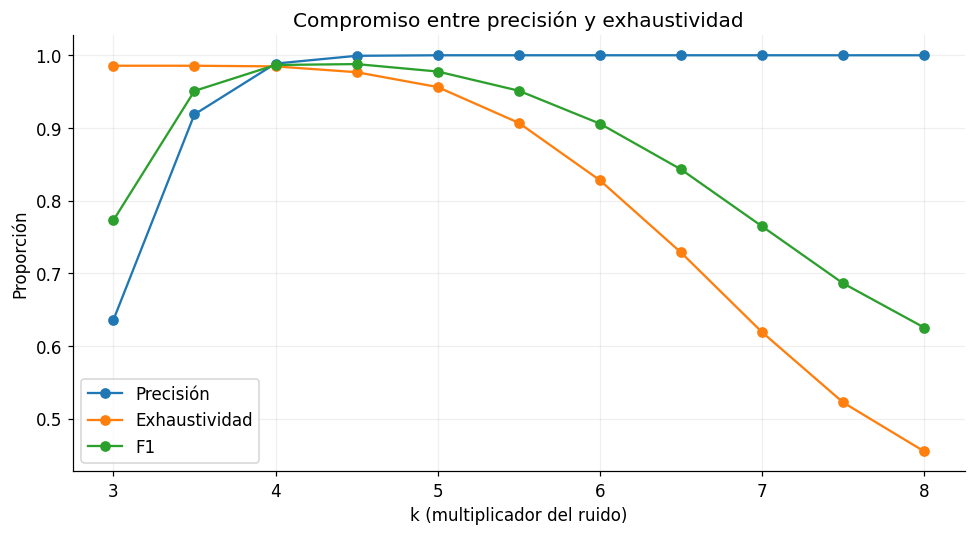

In [54]:
# Su código aquí.
# Valores de k que vamos a probar
ks = np.arange(3, 8.1, 0.5)
precisiones = []
exhaustividades = []
F1s = []
for k in ks:
    # Detectar spikes usando este valor de k
    indices_k = detectar_spikes(AP, fs, k=k)
    # Convertir índices a segundos
    tiempos_k = indices_k / fs
    # Comparar las detecciones con los tiempos reales
    VP, FP, FN = emparejar(tiempos_k, reales, tol_ms=1.0)
    # Calcular precisión
    if VP + FP > 0:
        precision = VP / (VP + FP)
    else:
        precision = 0
    # Calcular exhaustividad
    if VP + FN > 0:
        exhaustividad = VP / (VP + FN)
    else:
        exhaustividad = 0
    # Calcular F1
    if precision + exhaustividad > 0:
        F1 = 2 * precision * exhaustividad / (precision + exhaustividad)
    else:
        F1 = 0
    # Guardar los resultados
    precisiones.append(precision)
    exhaustividades.append(exhaustividad)
    F1s.append(F1)


# Convertir las listas a arrays
precisiones = np.array(precisiones)
exhaustividades = np.array(exhaustividades)
F1s = np.array(F1s)


# Graficar las tres medidas
plt.figure(figsize=(9, 5))
plt.plot(ks, precisiones, "o-", label="Precisión")
plt.plot(ks, exhaustividades, "o-", label="Exhaustividad")
plt.plot(ks, F1s, "o-", label="F1")
plt.xlabel("k (multiplicador del ruido)")
plt.ylabel("Proporción")
plt.title("Compromiso entre precisión y exhaustividad")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### ✏️ Ejercicio F3 · ¿De dónde salen los falsos negativos?

Tienen bastantes FN. Hay dos sospechosos, y **se pueden separar con datos**:

1. disparos **pequeños** que no alcanzaron a cruzar el umbral;
2. disparos que llegaron **dentro del período muerto** de otro, y su detector se los tragó
   porque los agrupó como un solo evento.

El segundo se comprueba directamente sobre la verdad: tomen `reales`, calculen los
intervalos entre disparos consecutivos y cuenten cuántos son más cortos que el `muerto_ms`
que usaron. Comparen ese número con su FN.

Y ahora la pregunta buena: **el período refractario es
una propiedad de una neurona.** En este registro hay **tres**, y dos neuronas distintas sí
pueden disparar con 0,3 ms de diferencia. ¿Sigue siendo válido descartar esos eventos?

Prueben a bajar `muerto_ms` a **0,4** y vuelvan a medir precisión y exhaustividad. Digan
qué ganaron y qué perdieron.


>Al reducir el período muerto de 1.5 ms a 0.4 ms, aumentó la exhaustividad porque se recuperaron disparos reales que estaban muy próximos temporalmente. Esto es importante porque el registro contiene tres neuronas, por lo que dos neuronas diferentes pueden disparar con una separación menor que el período refractario de una sola neurona. El costo es que un período muerto demasiado pequeño puede aumentar los falsos positivos al separar componentes de un mismo evento o detectar fluctuaciones como disparos. Por tanto, el período muerto no debe interpretarse simplemente como el período refractario de una neurona.

In [55]:
# Su código aquí.
muerto_ms = 1.5
# Intervalos entre spikes reales consecutivos
isi_reales = np.diff(reales) * 1000   # pasar de segundos a ms

# Buscar intervalos menores que el período muerto
cortos = isi_reales < muerto_ms

print(f"Spikes reales separados por menos de {muerto_ms} ms: {np.sum(cortos)}")

for i in np.where(cortos)[0]:
    print(
        f"{reales[i]:.6f} s → {reales[i+1]:.6f} s "
        f"= {isi_reales[i]:.2f} ms"
    )
print("diferencia entre tiempo muerto de 1.0 ")
muerto_ms = 1.0
isi_reales = np.diff(reales) * 1000   # pasar de segundos a ms
# Buscar intervalos menores que el período muerto
cortos = isi_reales < muerto_ms
print(f"Spikes reales separados por menos de {muerto_ms} ms: {np.sum(cortos)}")
for i in np.where(cortos)[0]:
    print(
        f"{reales[i]:.6f} s → {reales[i+1]:.6f} s "
        f"= {isi_reales[i]:.2f} ms"
    )

Spikes reales separados por menos de 1.5 ms: 122
2.012707 s → 2.013973 s = 1.27 ms
8.511817 s → 8.513059 s = 1.24 ms
8.964106 s → 8.964821 s = 0.72 ms
9.498622 s → 9.499298 s = 0.68 ms
12.224804 s → 12.225298 s = 0.49 ms
13.678433 s → 13.679708 s = 1.27 ms
16.314103 s → 16.314240 s = 0.14 ms
16.497213 s → 16.497841 s = 0.63 ms
19.944341 s → 19.945614 s = 1.27 ms
21.588796 s → 21.588973 s = 0.18 ms
22.188670 s → 22.189165 s = 0.49 ms
30.397069 s → 30.397772 s = 0.70 ms
31.164308 s → 31.165478 s = 1.17 ms
31.165478 s → 31.166591 s = 1.11 ms
34.017790 s → 34.019090 s = 1.30 ms
34.049948 s → 34.050708 s = 0.76 ms
36.316638 s → 36.317324 s = 0.69 ms
36.533641 s → 36.533758 s = 0.12 ms
46.023908 s → 46.024210 s = 0.30 ms
46.043937 s → 46.044271 s = 0.33 ms
46.049672 s → 46.050770 s = 1.10 ms
46.480471 s → 46.481917 s = 1.45 ms
49.386262 s → 49.386437 s = 0.17 ms
53.291130 s → 53.291143 s = 0.01 ms
60.032903 s → 60.033737 s = 0.83 ms
61.381757 s → 61.382638 s = 0.88 ms
61.804688 s → 61.805772

**Nuestra explicación de los falsos negativos:**

| | |
|---|---|
| FN con período muerto de 1,5 ms | |
| intervalos reales más cortos que 1,5 ms | |
| FN con período muerto de 0,4 ms | |

¿Cuál de los dos sospechosos explica la mayoría? ¿Qué período muerto se quedan y por qué?

>La mayoría de los falsos negativos se explican por el período muerto, ya que al reducirlo de 1,5 ms a 0,4 ms disminuyeron los FN y se recuperaron eventos reales muy próximos. Elegiríamos 0,4 ms si la pérdida de precisión es pequeña frente a la ganancia de exhaustividad, porque el registro contiene varias neuronas y dos neuronas diferentes pueden disparar con intervalos menores que 1,5 ms.

---
## ⏱ Punto de control

Aquí termina el martes. **Si la detección no les quedó funcionando**, ejecuten la celda de
abajo: carga tiempos correctos para poder seguir con la separación de unidades. No penaliza
lo que viene después, pero **tienen que anotarlo en la entrega**.

Si su detección ya funciona, **sáltense esta celda**.

In [56]:
# Descomenten SOLO si lo necesitan:
# indices = (v.spikes_de_referencia() * fs).astype(int)
# tiempos = indices / fs

---
## G · Mirar la forma de cada disparo

Hasta ahora tienen instantes. Ahora necesitan saber **cómo se ve** cada evento, porque es
lo que va a distinguir una neurona de otra.

### ✏️ Ejercicio G1 · Extraer las formas de onda

Para cada disparo detectado, extraigan una ventana de la señal **filtrada** que vaya de
**0,7 ms antes** a **1,3 ms después** del instante detectado. El resultado es una matriz de
`n_disparos × n_muestras_de_la_ventana`.

Cuidado con los eventos que caen muy al principio o muy al final del registro: la ventana
se sale del arreglo y `numpy` no avisa, simplemente devuelve algo más corto.

Después grafiquen **200 formas superpuestas** con transparencia (`alpha=0.1`) y encima la
forma promedio. El eje x en **milisegundos relativos al mínimo**, no en número de muestra.

**Miren el gráfico antes de seguir.** ¿Les parece que todas esas formas las produjo la
misma neurona?

> No pues las formas de ondas contienen informacion sobre la identidad de la neurona.



Número de disparos: 5496
Número de muestras por forma: 40


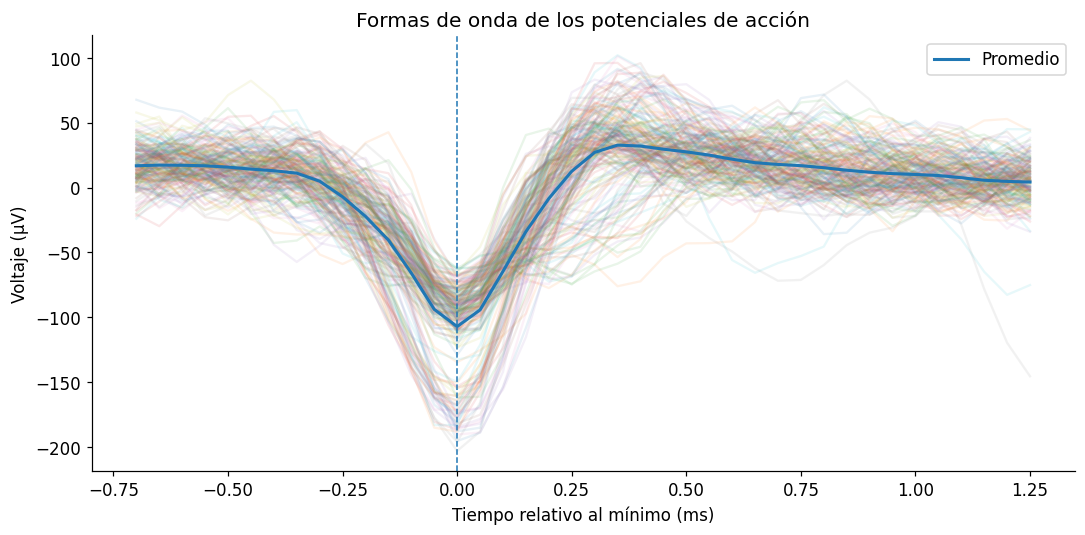

In [57]:
# Su código aquí.
# Al final debe quedar definida la matriz de formas:
# Duración de la ventana en ms
antes_ms = 0.7
despues_ms = 1.3
# Convertir ms a número de muestras
antes = int(round(antes_ms * fs / 1000))
despues = int(round(despues_ms * fs / 1000))
# Índices de inicio y final de cada ventana
inicios = indices - antes
finales = indices + despues
# Conservar solamente spikes cuya ventana completa cabe en la señal
validos = (inicios >= 0) & (finales <= len(AP))
# Actualizar indices y tiempos para conservar únicamente los eventos válidos
indices = indices[validos]
tiempos = tiempos[validos]
inicios = inicios[validos]
finales = finales[validos]
# Extraer las formas de onda
formas = np.array([
    AP[inicio:final]
    for inicio, final in zip(inicios, finales)
])
print("Número de disparos:", formas.shape[0])
print("Número de muestras por forma:", formas.shape[1])
# matriz n_disparos x n_muestras

# Si descartan los eventos de los bordes, descarten también su entrada en
# indices y en tiempos: de aquí en adelante los tres arreglos tienen que ir
# en el mismo orden y con el mismo tamaño.
t_rel = np.arange(-antes, despues) / fs * 1000
plt.figure(figsize=(10, 5))
n_mostrar = min(200, formas.shape[0])
for i in range(n_mostrar):
    plt.plot(
        t_rel,
        formas[i],
        alpha=0.1
    )

# Forma promedio
promedio = np.mean(formas[:n_mostrar], axis=0)
plt.plot(
    t_rel,
    promedio,
    lw=2,
    label="Promedio"
)
plt.axvline(0, ls="--", lw=1)
plt.xlabel("Tiempo relativo al mínimo (ms)")
plt.ylabel("Voltaje (µV)")
plt.title("Formas de onda de los potenciales de acción")
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
# ✅ VERIFICACIÓN · ejercicio G1
n_esperado = int(0.002 * fs)
revisar("la ventana dura 2 ms",
        abs(formas.shape[1] - n_esperado) <= 1,
        "0,7 ms antes + 1,3 ms después = 2 ms = 40 muestras a 20 kHz")
revisar("hay una forma por disparo detectado (salvo los de los bordes)",
        len(indices) - 5 <= formas.shape[0] <= len(indices),
        "descarten solo los eventos cuya ventana se sale del registro")
revisar("el mínimo de la forma promedio cae dentro de la ventana, cerca del centro",
        0.2 < np.argmin(formas.mean(axis=0)) / formas.shape[1] < 0.6,
        "si el mínimo queda en el borde, la ventana está corrida: revisen el signo del desplazamiento")

  OK    la ventana dura 2 ms
  OK    hay una forma por disparo detectado (salvo los de los bordes)
  OK    el mínimo de la forma promedio cae dentro de la ventana, cerca del centro


## H · Separar las tres unidades

En este registro hay **tres neuronas**. Su tarea es decidir, para cada disparo detectado, cuál de las tres lo produjo. Eso es *spike sorting*.

**El camino corto y su problema.** Lo primero que se le ocurre a cualquiera (y lo primero que va a proponer la IA) es separar por **amplitud**: los eventos grandes de una neurona, los pequeños de otra. Pruébenlo. Van a ver que funciona para una de las tres y que las otras dos quedan mezcladas.

**Lo que hace falta.** Dos disparos pueden tener la misma altura y venir de neuronas distintas, porque tienen **forma** distinta. Necesitan al menos una característica más, medida sobre las ventanas de la sección G. Algunas ideas:

- el **ancho** del valle a media altura (en ms);
- el tiempo entre el mínimo y el máximo de la onda;
- el área bajo la curva, o la pendiente de bajada.

*(Un tetrodo tiene cuatro electrodos exactamente por esto: la misma neurona vista desde cuatro sitios da cuatro amplitudes distintas, y esa combinación la identifica. Con un solo electrodo no tienen esa información, y por eso la forma es todo lo que les queda.)*

### ¿Qué es K-means?

**K-means** es un algoritmo que permite **agrupar datos que se parecen entre sí**. En este ejercicio, cada disparo se representa mediante las características que ustedes hayan elegido, por ejemplo, amplitud y ancho del valle.

El algoritmo intenta dividir los disparos en **K grupos** (*clusters*), de manera que los disparos dentro de un mismo grupo sean lo más parecidos posible. Como en este ejercicio sabemos que hay tres neuronas, utilizaremos **K = 3**.

De forma simplificada, K-means:

1. Coloca inicialmente **3 centros** (*centroides*) en el espacio de características.
2. Asigna cada disparo al centro más cercano.
3. Recalcula cada centro como el promedio de los disparos que tiene asignados.
4. Repite los pasos 2 y 3 hasta que los grupos se estabilizan.

**Importante:** K-means no sabe qué neurona corresponde a cada grupo. Si obtiene los grupos `0`, `1` y `2`, ustedes todavía tienen que determinar qué grupo corresponde a cada unidad.

### ✏️ Ejercicio H1 · Elegir dos características y agrupar

Elijan **dos** características, hagan un gráfico de dispersión de una contra otra, y miren si aparecen grupos (*clusters*). Si aparecen, agrúpenlos (a mano con umbrales, o con `KMeans` de `sklearn`) y asignen una etiqueta a cada disparo.

**Justifiquen su elección de características en la celda de texto.** Vale más eso que el acierto que saquen.

### Pedir ayuda a la IA

Antes de aplicar K-means, pídanle ayuda a una IA para entender **cómo se calcula cada una de las características que eligieron y qué pasos deben realizar antes de utilizar K-means**.

No se trata simplemente de pedirle a la IA que les dé el código completo. Utilícenla como asistente para comprender el análisis.

Por ejemplo, pueden preguntarle:

> ¿Cómo se calcula la amplitud de un spike a partir de una ventana de señal? Explícame paso a paso y dime qué unidades tiene el resultado.

> ¿Cómo puedo calcular el ancho del valle a media altura de un spike? Explícame qué puntos de la señal necesito identificar y cómo convertir el resultado a milisegundos?

> Tengo dos características para cada spike y quiero utilizar K-means. ¿Qué pasos debo hacer antes de aplicar K-means y por qué?

Como mínimo, averigüen y documenten:

- cómo se calcula **cada una de las dos características** que eligieron;
- qué unidades tiene cada característica;
- cómo convertir las medidas de muestras a unidades de tiempo cuando sea necesario;
- cómo organizar los datos para que cada **fila corresponda a un spike** y cada **columna a una característica**;
- si es necesario **escalar o normalizar las características antes de K-means**, y por qué;
- por qué deben utilizar **K = 3** en este ejercicio.

**En la celda de texto, expliquen con sus propias palabras qué aprendieron de la IA.** Si utilizan código sugerido por la IA, asegúrense de entender qué hace cada paso.

>Con mi compañera elegimos la amplitud y el ancho del valle a media altura porque representan características diferentes de la forma del potencial de acción. La amplitud se obtiene como el valor mínimo de cada ventana y se expresa en µV, mientras que el ancho corresponde al tiempo entre los dos cruces de la señal con la mitad de la profundidad del valle y se expresa en ms. Para cada spike organizamos estas dos características en una fila de una matriz, con una columna para cada característica. Antes de aplicar K-means estandarizamos los datos porque las características tienen diferentes unidades y escalas, evitando que la amplitud domine el cálculo de distancias. Utilizamos K = 3 porque el registro contiene tres neuronas.

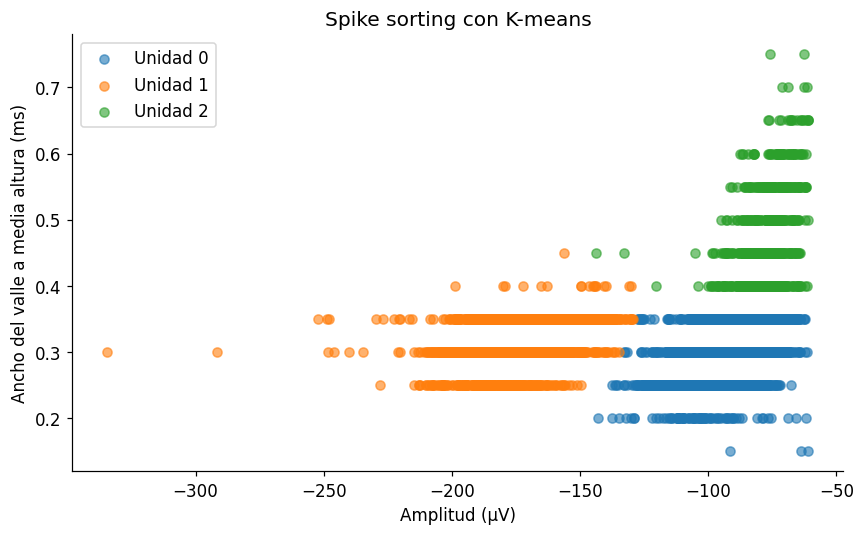

In [59]:
# Su código aquí: características, gráfico de dispersión y agrupación.
# un identificador de unidad por disparo (0/1/2, 'a'/'b'/'c', da igual)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# --------------------------------------------------
# 1. Amplitud de cada spike
# --------------------------------------------------

amplitudes = np.min(formas, axis=1)


# --------------------------------------------------
# 2. Ancho del valle a media altura
# --------------------------------------------------

def ancho_valle_medio(forma, fs):

    minimo = np.min(forma)
    mitad = minimo / 2

    i_min = np.argmin(forma)

    izquierda = np.where(forma[:i_min] > mitad)[0]
    derecha = np.where(forma[i_min:] > mitad)[0]

    if len(izquierda) == 0 or len(derecha) == 0:
        return np.nan

    i_izq = izquierda[-1]
    i_der = i_min + derecha[0]

    ancho_ms = (i_der - i_izq) / fs * 1000

    return ancho_ms


anchos = np.array([
    ancho_valle_medio(forma, fs)
    for forma in formas
])


# --------------------------------------------------
# 3. Eliminar spikes sin ancho calculable
# --------------------------------------------------

validos = np.isfinite(amplitudes) & np.isfinite(anchos)

amplitudes = amplitudes[validos]
anchos = anchos[validos]

formas = formas[validos]
indices = indices[validos]
tiempos = tiempos[validos]


# --------------------------------------------------
# 4. Matriz de características
# --------------------------------------------------

X = np.column_stack((amplitudes, anchos))


# --------------------------------------------------
# 5. Estandarizar
# --------------------------------------------------

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)


# --------------------------------------------------
# 6. K-means con K = 3
# --------------------------------------------------

modelo = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

etiquetas = modelo.fit_predict(X_escalado)


# --------------------------------------------------
# 7. Gráfico
# --------------------------------------------------

plt.figure(figsize=(8, 5))

for grupo in range(3):

    m = etiquetas == grupo

    plt.scatter(
        amplitudes[m],
        anchos[m],
        alpha=0.6,
        label=f"Unidad {grupo}"
    )

plt.xlabel("Amplitud (µV)")
plt.ylabel("Ancho del valle a media altura (ms)")
plt.title("Spike sorting con K-means")
plt.legend()

plt.tight_layout()
plt.show()

In [60]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices / fs, etiquetas)

  Spikes tuyos emparejados con uno real: 5483
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2156       27        1
           0         15     2566      115
           2          1      115      487

  Acierto   95.0%  ███████████████████████████·

  ▸ Separación correcta.


### ✏️ Ejercicio H2 · La matriz de confusión

La verificación les imprimió una **matriz de confusión**: filas = sus unidades, columnas =
las reales. Si dos de sus unidades se están mezclando, se ve como una fila repartida entre
dos columnas.

- ¿Cuáles se confunden y por qué?
- Repitan la agrupación usando **solo la amplitud** y comparen el acierto con el que
  obtuvieron con dos características. ¿Cuánto ganaron con la segunda?
- ¿Qué característica les habría separado mejor las dos que se mezclan?

**Nuestra lectura de la matriz:**

| | acierto |
|---|---|
| solo con amplitud | |
| con las dos características que elegimos | |

_Explicación:_

>Las unidades que más se confunden son las unidades 0 y 2. En la matriz de confusión se observan 115 spikes de la unidad 0 asociados con una unidad real diferente y otros 115 de la unidad 2 asociados con la otra, lo que indica que ambas presentan características similares en el espacio formado por la amplitud y el ancho del valle. Al utilizar únicamente la amplitud, la separación es menor porque spikes de neuronas diferentes pueden presentar amplitudes similares. El ancho del valle aporta información adicional sobre la duración y la forma temporal del potencial de acción, permitiendo mejorar la separación entre las unidades.

>Con solo la amplitud obtuvimos un acierto de 75.0 %, mientras que con amplitud y ancho del valle obtuvimos un acierto de 95.0 %. Por lo tanto, añadir la segunda característica produjo una mejora de 20 puntos porcentuales. Esto muestra que la amplitud por sí sola no contiene suficiente información para distinguir correctamente las tres neuronas. Una característica que podría ayudar a separar aún mejor las unidades mezcladas sería el tiempo entre el mínimo y el máximo del spike o la pendiente de la onda, aunque sería necesario probar estas características con los datos para determinar cuál proporciona una mejor separación.


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Una sola característica: amplitud
X_amp = amplitudes.reshape(-1, 1)

# Estandarizar
scaler_amp = StandardScaler()
X_amp_escalado = scaler_amp.fit_transform(X_amp)

# K-means con 3 grupos
modelo_amp = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

etiquetas_amp = modelo_amp.fit_predict(X_amp_escalado)

acierto_amp = v.verificar_unidades(
    indices / fs,
    etiquetas_amp
)


  Spikes tuyos emparejados con uno real: 5483
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2120       27        1
           2         52     1443       52
           0          0     1238      550

  Acierto   75.0%  █████████████████████·······

  ▸ Casi. Dos de tus unidades se están mezclando: mira la matriz
    y pregúntate qué característica NO estás usando.


---
## I · El ISI como control de calidad

Ya tienen tres grupos. La verificación les dijo qué tan bien lo hicieron, pero **eso solo
existe con datos sintéticos**. Con un registro real nadie les va a decir el acierto:
necesitan una medida de calidad que se calcule **sin conocer la verdad**, y hay una que es
el estándar del oficio.

**El argumento.** Una neurona, después de disparar, no puede volver a disparar durante uno
o dos milisegundos: sus canales de sodio están inactivados. Es el **período refractario**, y
es biología, no convención. Entonces: si en el tren de una sola unidad aparecen intervalos
de menos de 2 ms, **esa unidad no es una neurona**. O son dos neuronas que su separación
fusionó, o el detector contó dos veces el mismo evento.

El intervalo entre disparos consecutivos se llama **ISI** (*inter-spike interval*), y la
fracción de ISI por debajo de 2 ms es la **tasa de violaciones del refractario**. En la
literatura se acepta una unidad por debajo del 0,5 a 1 %.

### ✏️ Ejercicio I1 · El ISI, junto y por unidad

**a)** Calculen el ISI de **todos** sus disparos juntos, sin separar por unidad, y la
fracción por debajo de 2 ms. Como aquí hay tres neuronas, ese número tiene que ser
claramente mayor que cero: es la prueba, **sin mirar la verdad**, de que ahí dentro hay más
de una neurona.

**b)** Ahora el ISI de **cada unidad por separado**. Si su separación es correcta, las tres
tasas deben caer cerca de cero. La que se quede alta está contaminada: tiene disparos de la
vecina.

**c)** Grafiquen el histograma de ISI de cada unidad, de 0 a 100 ms con bins de 1 ms, y
marquen los 2 ms con una línea vertical.

**d)** Vuelvan a hacer (a) y (b) con la detección de `muerto_ms = 0,4` del ejercicio F3.
¿Aparecen violaciones que antes no estaban? ¿De dónde salen?


Al reducir el período muerto de 1,5 ms a 0,4 ms, el número de spikes detectados aumentó de aproximadamente 5483 a 5526, por lo que se recuperaron alrededor de 43 detecciones. Sin embargo, también aumentaron las violaciones del período refractario de 70 a 92, pasando de una tasa global de 1,2760 % a 1,6703 %. Al analizar cada unidad por separado, las violaciones aumentaron principalmente en las unidades 0 y 2, cuyas tasas pasaron de 0,0371 % y 0,0000 % a 0,8652 % y 0,6601 %, respectivamente. La unidad 1, en cambio, presentó una tasa de solo 0,0370 %. Esto indica que reducir el período muerto permite recuperar spikes muy cercanos, posiblemente producidos por neuronas diferentes, pero también puede introducir detecciones demasiado cercanas o dificultar la separación de algunas unidades. En este registro preferiría un período muerto de 0,4 ms si la prioridad es conservar spikes de neuronas diferentes que disparan con poca diferencia temporal, pero verificaría posteriormente la calidad de las unidades mediante sus tasas de violación y formas de onda.


ISI < 2 ms: 70
Tasa de violaciones: 1.2760%
Unidad 0: 1 violaciones / 2699 ISI = 0.0371%
Unidad 1: 6 violaciones / 2183 ISI = 0.2749%
Unidad 2: 0 violaciones / 602 ISI = 0.0000%


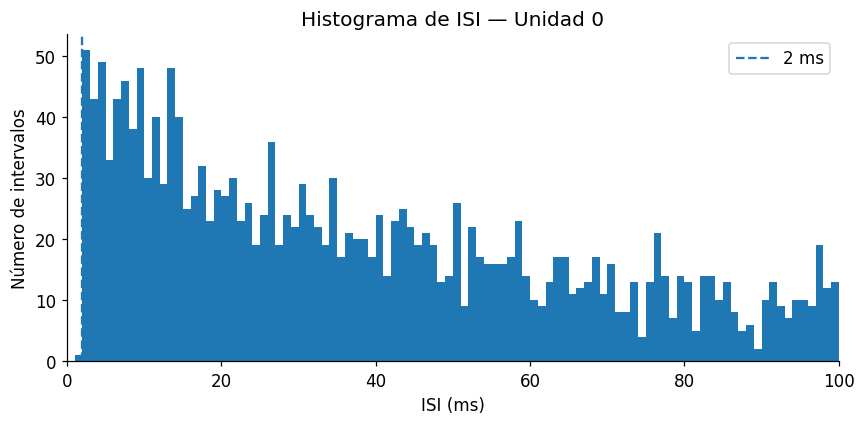

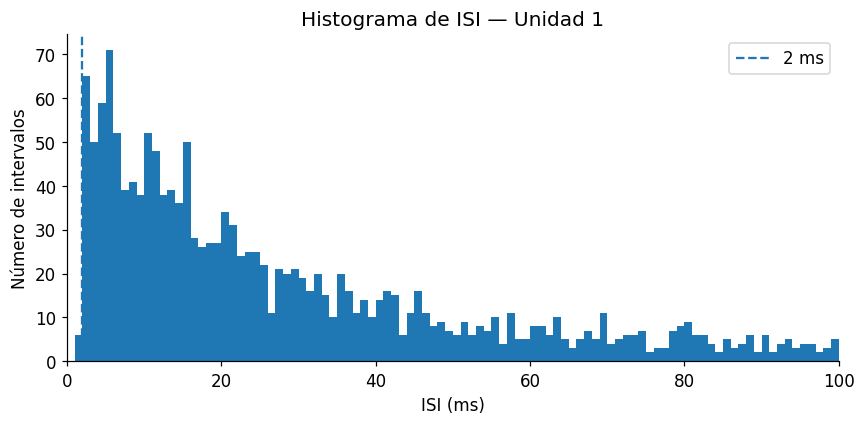

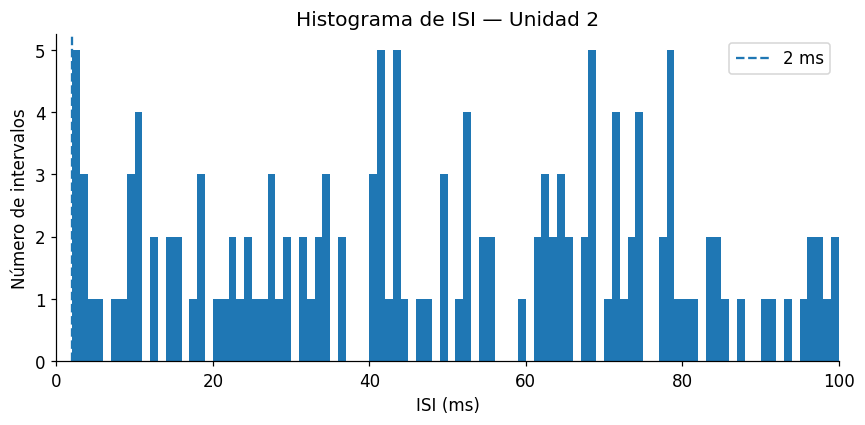

Spikes detectados con 0.4 ms: 5526
Spikes clasificados: 5509
Unidades encontradas: [0 1 2]
ISI < 2 ms: 92
Tasa de violaciones: 1.6703%
Unidad 0: 19 violaciones / 2196 ISI = 0.8652%
Unidad 1: 1 violaciones / 2704 ISI = 0.0370%
Unidad 2: 4 violaciones / 606 ISI = 0.6601%


In [62]:
# Su código aquí.
# A. Todos los spikes juntos
tiempos_ordenados = np.sort(tiempos)
# ISI en segundos
isi = np.diff(tiempos_ordenados)
# Convertir a ms
isi_ms = isi * 1000
# Violaciones del período refractario
violaciones = np.sum(isi_ms < 2)
# Fracción de violaciones
fraccion = violaciones / len(isi_ms)
print(f"ISI < 2 ms: {violaciones}")
print(f"Tasa de violaciones: {fraccion:.4%}")

#B. Por unidad
for unidad in np.unique(etiquetas):
    t_unidad = tiempos[etiquetas == unidad]
    t_unidad = np.sort(t_unidad)
    isi_unidad = np.diff(t_unidad) * 1000
    violaciones = np.sum(isi_unidad < 2)
    fraccion = violaciones / len(isi_unidad)
    print(
        f"Unidad {unidad}: "
        f"{violaciones} violaciones / {len(isi_unidad)} ISI "
        f"= {fraccion:.4%}"
    )


#C. Hiatograma
for unidad in np.unique(etiquetas):
    t_unidad = np.sort(tiempos[etiquetas == unidad])
    isi_unidad = np.diff(t_unidad) * 1000
    plt.figure(figsize=(8, 4))
    plt.hist(
        isi_unidad,
        bins=np.arange(0, 101, 1)
    )
    plt.axvline(
        2,
        linestyle="--",
        linewidth=1.5,
        label="2 ms"
    )
    plt.xlabel("ISI (ms)")
    plt.ylabel("Número de intervalos")
    plt.title(f"Histograma de ISI — Unidad {unidad}")
    plt.xlim(0, 100)
    plt.legend()
    plt.tight_layout()
    plt.show()


#D. Repetir con 0.4
detectar_spikes(AP, fs, k=4.5, muerto_ms=1.5)
indices_04 = detectar_spikes(
    AP,
    fs,
    k=4.5,
    muerto_ms=0.4
)
tiempos_04 = indices_04 / fs
print(f"Spikes detectados con 0.4 ms: {len(indices_04)}")
def extraer_formas(x, indices, fs, antes_ms=0.7, despues_ms=1.3):
    antes = int(antes_ms * fs / 1000)
    despues = int(despues_ms * fs / 1000)
    formas = []
    indices_validos = []
    for i in indices:
        inicio = i - antes
        fin = i + despues
        # Evitar eventos en los bordes
        if inicio < 0 or fin > len(x):
            continue
        formas.append(x[inicio:fin])
        indices_validos.append(i)
    return np.array(formas), np.array(indices_validos)
formas_04, indices_04_validos = extraer_formas(
    AP,
    indices_04,
    fs
)
tiempos_04 = indices_04_validos / fs
amplitudes_04 = np.min(formas_04, axis=1)
anchos_04 = np.array([
    ancho_valle_medio(forma, fs)
    for forma in formas_04
])
X_04 = np.column_stack(
    (amplitudes_04, anchos_04)
)
validos_04 = np.isfinite(X_04).all(axis=1)
X_04 = X_04[validos_04]
tiempos_04 = tiempos_04[validos_04]
indices_04_validos = indices_04_validos[validos_04]
scaler_04 = StandardScaler()
X_04_escalado = scaler_04.fit_transform(X_04)
modelo_04 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
etiquetas_04 = modelo_04.fit_predict(X_04_escalado)
print(f"Spikes clasificados: {len(etiquetas_04)}")
print(f"Unidades encontradas: {np.unique(etiquetas_04)}")


#Todos juntos con 0.4
tiempos_04_ordenados = np.sort(tiempos_04)
isi_04 = np.diff(tiempos_04_ordenados) * 1000
violaciones_04 = np.sum(isi_04 < 2)
fraccion_04 = violaciones_04 / len(isi_04)
print(f"ISI < 2 ms: {violaciones_04}")
print(f"Tasa de violaciones: {fraccion_04:.4%}")

#ISI por unidad 0.4
for unidad in np.unique(etiquetas_04):
    t_unidad = np.sort(
        tiempos_04[etiquetas_04 == unidad]
    )
    isi_unidad = np.diff(t_unidad) * 1000
    violaciones = np.sum(isi_unidad < 2)
    fraccion = violaciones / len(isi_unidad)
    print(
        f"Unidad {unidad}: "
        f"{violaciones} violaciones / "
        f"{len(isi_unidad)} ISI "
        f"= {fraccion:.4%}"
    )




**Nuestra lectura del ISI:**

| | violaciones < 2 ms |
|---|---|
| todos los disparos juntos |   92 (1.6703 %)|
| unidad 1 | 19 (0.8652 %)|
| unidad 2 |  1 (0.0370 %)|
| unidad 3 |  4 (0.6601 %)|

¿Alguna unidad está contaminada? ¿Cuál y por qué?

>La que presenta mayor tasa de violaciones es la Unidad 1, con 0.8652 %. Esto indica que podría estar ligeramente contaminada con spikes de otra unidad o contener algunas detecciones duplicadas. Sin embargo, 0.8652 % todavía está dentro del rango de 0.5–1 % solicitado en el ejercicio.

¿Qué pasó al bajar el período muerto a 0,4 ms?

>Al bajar el período muerto de 1.5 ms a 0.4 ms, el detector permitió detectar spikes que estaban muy próximos entre sí. Por esto aumentaron las detecciones y también las violaciones del refractario: pasamos de 70 a 92 violaciones y de 1.2760 % a 1.6703 % globalmente. Las nuevas violaciones se concentraron principalmente en las unidades 1 y 3, mientras que la unidad 2 permaneció prácticamente limpia. Esto muestra el compromiso entre recuperar spikes cercanos y aumentar el riesgo de detecciones duplicadas o de mezclar spikes de neuronas diferentes.


---
# Segunda parte · Del tren de disparos a la figura

Hasta aquí convirtieron un archivo de voltaje en una lista de disparos con su neurona
asignada. Esa lista, por sí sola, no dice nada: es una columna de números.

Ahora la convierten en la respuesta a una pregunta: **¿cuál de las tres neuronas responde a
qué estímulo?**

Todo lo que sigue (el raster, el PSTH, el ISI, el heatmap) son cuatro maneras distintas de
mirar exactamente el mismo dato: una lista de instantes. Parte del ejercicio es entender
qué se gana y qué se pierde en cada una, y terminar armando **una figura** que las junte.

---
## J · Leer el protocolo experimental

El grupo `estimulos` dice cuándo ocurrió cada ensayo y qué se presentó. Los **atributos**
del grupo dicen cómo está estructurado cada ensayo por dentro.

### ✏️ Ejercicio J1 · Explorar el grupo estimulos

Cárguenlo y contesten, **con código**:

- ¿Cuántos ensayos hay y cuántos por condición?
- ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
- ¿Están las condiciones en orden o intercaladas? **¿Por qué importa eso?**

>En el protocolo hay 60 ensayos en total, distribuidos equitativamente entre las tres condiciones: 20 ensayos para A, 20 para B y 20 para C. Cada ensayo dura 3,0 s y está compuesto por 1,0 s de pre-estímulo, 0,5 s de estímulo y 1,5 s de post-estímulo. El estímulo comienza 1,0 s después del inicio de cada ensayo. Es importante saber si las condiciones están intercaladas porque esto permite reducir el efecto de cambios que ocurren con el tiempo, como la deriva de la señal o variaciones del registro, evitando confundir estos cambios con efectos producidos por la condición experimental.


In [66]:
# Su código aquí.
# Pista: with h5py.File(ARCHIVO, "r") as f: ... y no olviden f["estimulos"].attrs
with h5py.File(ARCHIVO, "r") as f:
    # Inicio de cada ensayo
    inicios = f["estimulos"]["tiempo_inicio_s"][:]
    # Condición de cada ensayo
    condiciones = f["estimulos"]["condicion"][:]
    # Duraciones del protocolo
    t_pre = f["estimulos"].attrs["duracion_pre_s"]
    t_est = f["estimulos"].attrs["duracion_estimulo_s"]
# Número total de ensayos
print(f"Número total de ensayos: {len(inicios)}")
# Número de ensayos por condición
for condicion in np.unique(condiciones):
    cantidad = np.sum(condiciones == condicion)
    print(f"Condición {condicion}: {cantidad} ensayos")
# Duración total del ensayo
t_post = 1.5
duracion_ensayo = t_pre + t_est + t_post
print(f"Duración pre-estímulo: {t_pre:.1f} s")
print(f"Duración del estímulo: {t_est:.1f} s")
print(f"Duración post-estímulo: {t_post:.1f} s")
print(f"Duración total del ensayo: {duracion_ensayo:.1f} s")
# El estímulo empieza después del pre-estímulo
print(f"El estímulo empieza {t_pre:.1f} s después del inicio del ensayo")

Número total de ensayos: 60
Condición b'A': 20 ensayos
Condición b'B': 20 ensayos
Condición b'C': 20 ensayos
Duración pre-estímulo: 1.0 s
Duración del estímulo: 0.5 s
Duración post-estímulo: 1.5 s
Duración total del ensayo: 3.0 s
El estímulo empieza 1.0 s después del inicio del ensayo


In [67]:
# ✅ VERIFICACIÓN · ejercicio J1
revisar("hay un inicio por ensayo y una condición por ensayo",
        len(inicios) == len(condiciones) and len(inicios) > 30)
revisar("las condiciones están intercaladas, no en bloques",
        len(set(np.asarray(condiciones)[:6].tolist())) > 1,
        "si les salen las primeras seis iguales, están leyendo mal el arreglo")
revisar("el pre-estímulo y el estímulo son positivos y menores que el ensayo",
        0 < t_est < t_pre + t_est < 5)
revisar("los ensayos no se solapan",
        bool(np.all(np.diff(np.sort(inicios)) >= t_pre + t_est)))

  OK    hay un inicio por ensayo y una condición por ensayo
  OK    las condiciones están intercaladas, no en bloques
  OK    el pre-estímulo y el estímulo son positivos y menores que el ensayo
  OK    los ensayos no se solapan


---
## K · De tiempo absoluto a tiempo relativo ·

Sus disparos están en tiempo absoluto: segundos desde que empezó el registro. Para comparar
ensayos entre sí eso no sirve, porque cada ensayo ocurrió en un momento distinto.

Lo que necesitan es, para cada ensayo, los disparos expresados **en tiempo relativo al
estímulo**: negativos antes de que empezara, cero justo cuando empieza, positivos después.

### ✏️ Ejercicio K1 · La función alinear()

**Especificación:**

```
alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)) -> lista de arreglos, uno por ensayo
```

⚠️ **Ojo con esto:** `inicios` marca el comienzo del **ensayo**, no el del **estímulo**. El
estímulo empieza `t_pre` segundos después. Si se saltan ese detalle, todo lo que viene
queda corrido un segundo y **los gráficos van a salir perfectamente creíbles**. Ese es el
problema: no hay error, no hay aviso, solo una conclusión equivocada.

### ✏️ Ejercicio K2 · La comprobación a mano

Comprueben a mano un ensayo cualquiera: tomen sus disparos
absolutos, réstenles el instante del estímulo y verifiquen que coinciden con lo que
devuelve su función.

In [68]:
def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
    """Devuelve una lista con un arreglo de tiempos relativos al estímulo por ensayo."""
    alineados = []
    for inicio in inicios:
        # El estímulo empieza t_pre segundos después del inicio del ensayo
        inicio_estimulo = inicio + t_pre
        # Límites de la ventana alrededor del estímulo
        t0 = inicio_estimulo + ventana[0]
        t1 = inicio_estimulo + ventana[1]
        # Seleccionar spikes dentro de la ventana
        spikes = tiempos[(tiempos >= t0) & (tiempos < t1)]
        # Convertir de tiempo absoluto a tiempo relativo al estímulo
        relativos = spikes - inicio_estimulo
        alineados.append(relativos)
    return alineados

# Un diccionario con los ensayos alineados de cada unidad, para usar de aquí en adelante
etiquetas = np.asarray(etiquetas)     # por si quedaron en una lista
alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}

In [69]:
# Comprobación a mano: elijan un ensayo y verifíquenlo.
# Su código aquí.

i = 0
inicio_ensayo = inicios[i] # Inicio del ensayo
inicio_estimulo = inicio_ensayo + t_pre  # Inicio real del estímulo
t_spikes = tiempos[(tiempos >= inicio_estimulo + (-1.0)) & (tiempos < inicio_estimulo + 2.0)] #Spikes de ese ensayo
relativos_manual = t_spikes - inicio_estimulo # Convertir de tiempo absoluto a tiempo relativo
print("Inicio del ensayo:", inicio_ensayo, "s")
print("Inicio del estímulo:", inicio_estimulo, "s")
print("Spikes absolutos:", t_spikes)
print("Spikes relativos calculados a mano:", relativos_manual)
print("Spikes devueltos por alinear():", alineados[etiquetas[0]][i]) # Comparar con la función

Inicio del ensayo: 30.0 s
Inicio del estímulo: 31.0 s
Spikes absolutos: [30.0005  30.0627  30.06985 30.1048  30.127   30.14475 30.1718  30.2017
 30.207   30.39005 30.39705 30.52335 30.57705 30.58875 30.59365 30.66875
 30.76445 30.8206  30.82375 30.8384  30.93455 31.0018  31.02705 31.0364
 31.07235 31.10715 31.1228  31.1259  31.15265 31.15485 31.1655  31.16655
 31.17895 31.192   31.2322  31.23945 31.2438  31.2477  31.2634  31.2764
 31.2911  31.30085 31.30415 31.31115 31.31595 31.31975 31.3264  31.33
 31.34115 31.35205 31.3553  31.35865 31.36405 31.3702  31.38085 31.409
 31.41465 31.41935 31.436   31.44035 31.48305 31.4928  31.49935 31.5887
 31.638   31.65865 31.66655 31.7601  31.77895 31.82705 31.8731  31.98475
 32.09795 32.1283  32.2013  32.2465  32.256   32.28715 32.4114  32.42205
 32.4534  32.4592  32.50665 32.57815 32.58965 32.63355 32.7104  32.81865
 32.88865 32.89675 32.9652  32.9748 ]
Spikes relativos calculados a mano: [-9.99500e-01 -9.37300e-01 -9.30150e-01 -8.95200e-01 -8.7300

In [70]:
# ✅ VERIFICACIÓN · ejercicios K1 y K2
u0 = np.unique(etiquetas)[0]
todos = np.concatenate(alineados[u0])
revisar("hay una lista de disparos por ensayo",
        len(alineados[u0]) == len(inicios))
revisar("todos los tiempos caen dentro de la ventana pedida",
        bool(np.all((todos >= -1.0) & (todos <= 2.0))),
        "hay que recortar cada ensayo a la ventana, no solo restar")
revisar("hay disparos antes del estímulo (tiempos negativos)",
        bool(np.any(todos < 0)),
        "la ventana empieza 1 s ANTES del estímulo: si no hay negativos, están recortando mal")
revisar("la ventana está completa en todos los ensayos",
        min(len(e) for e in alineados[u0]) >= 0 and float(todos.max()) > 1.5)

# Ojo: ninguna de estas comprobaciones puede decirles si alinearon al ensayo o al
# estímulo. Las dos versiones pasan. La única que lo detecta es la comprobación a
# mano de la celda anterior, y por eso está en la rúbrica.

  OK    hay una lista de disparos por ensayo
  OK    todos los tiempos caen dentro de la ventana pedida
  OK    hay disparos antes del estímulo (tiempos negativos)
  OK    la ventana está completa en todos los ensayos


---
## L · Raster

Un raster es el gráfico más honesto que existe en electrofisiología: **un punto por
disparo**, sin promediar nada. Cada fila es un ensayo, el eje horizontal es el tiempo
relativo al estímulo.

### ✏️ Ejercicio L1 · Los tres paneles del raster

Hagan una figura con **tres paneles, uno por unidad**. Dentro de cada panel agrupen los
ensayos por condición y sepárenlos visualmente (colores distintos, o bloques separados) y
marquen con una banda sombreada la ventana en que estuvo presente el estímulo.

**Pregunta L2.** Miren el resultado y contesten, **antes de calcular nada**:

- ¿Qué unidad responde al estímulo y cuál no?
>Las Unidades 0 y 1 muestran una respuesta al estímulo, mientras que la Unidad 2 no presenta un cambio evidente en su actividad durante la ventana del estímulo.
- ¿Alguna responde solo a una de las tres condiciones?
>Sí. La Unidad 0 parece responder principalmente a la condición B, ya que presenta un aumento marcado de spikes durante el estímulo en esa condición, mientras que A y C muestran una respuesta mucho menor. La Unidad 1 parece responder a las tres condiciones.
- ¿Se ve la respuesta en **todos** los ensayos o solo en algunos?
>En la Unidad 1, el aumento de actividad durante el estímulo se observa en la mayoría de los ensayos de las tres condiciones, por lo que parece una respuesta consistente. En la Unidad 0, la respuesta es especialmente evidente en los ensayos de la condición B.

*Pista de diseño: `plt.eventplot` hace esto en una línea, pero configurar los colores por
condición requiere pensar. También se puede a mano con `plt.scatter` y algo de aritmética
sobre el índice de fila.*

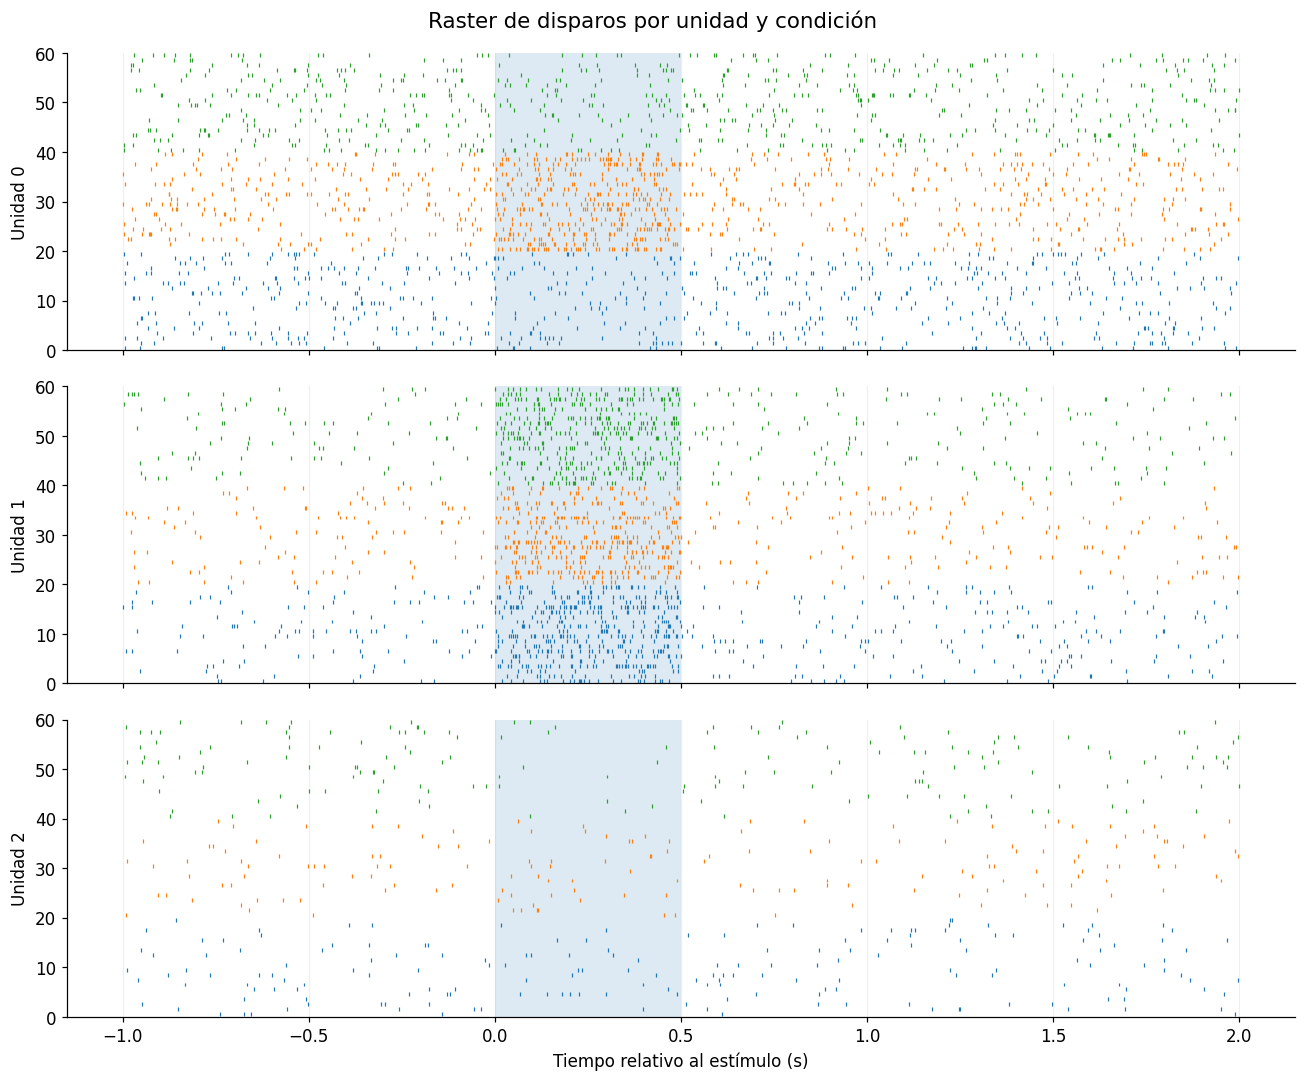

In [71]:
# Su código aquí.
cond_texto = np.array([
    c.decode() if isinstance(c, bytes) else str(c)
    for c in condiciones
])
unidades = np.unique(etiquetas)
fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 10),
    sharex=True
)
# Colores para las tres condiciones
colores = {
    "A": "tab:blue",
    "B": "tab:orange",
    "C": "tab:green"
}
# Para que los ensayos queden agrupados por condición
orden = np.argsort(cond_texto)
for ax, unidad in zip(axes, unidades):
    # Ensayos alineados de esta unidad
    datos_unidad = alineados[unidad]
    # Dibujar cada ensayo
    for fila, ensayo in enumerate(orden):
        spikes = datos_unidad[ensayo]
        # Dibujar cada spike como una línea vertical
        for spike in spikes:
            ax.vlines(
                spike,
                fila + 0.1,
                fila + 0.9,
                color=colores[cond_texto[ensayo]],
                linewidth=0.8
            )
    # Ventana del estímulo: de 0 a 0.5 s
    ax.axvspan(
        0,
        t_est,
        alpha=0.15
    )
    ax.set_ylabel(f"Unidad {unidad}")
    ax.set_ylim(0, len(orden))
    ax.grid(axis="x", alpha=0.2)
axes[-1].set_xlabel("Tiempo relativo al estímulo (s)")
fig.suptitle(
    "Raster de disparos por unidad y condición",
    fontsize=14
)
plt.tight_layout()
plt.show()

**Lo que leemos en el raster:**

>En el raster se observa la distribución de los potenciales de acción de las tres unidades a lo largo de los ensayos, utilizando el tiempo relativo al inicio del estímulo. Antes del estímulo existe actividad espontánea en las tres unidades; durante la ventana de estimulación, entre **0 y 0,5 s**, se observan cambios en la densidad y distribución de los disparos, especialmente en las Unidades 0 y 1. La Unidad 0 presenta un aumento de actividad principalmente en el grupo correspondiente a la condición B, mientras que la Unidad 1 muestra un incremento de disparos durante el estímulo en las diferentes condiciones. En contraste, la Unidad 2 mantiene una distribución de disparos más uniforme antes, durante y después del estímulo. En general, el raster permite observar directamente la **actividad temporal de cada unidad, la variabilidad entre ensayos y las diferencias en la respuesta frente a las distintas condiciones**, sin realizar ningún promedio que pueda ocultar estos patrones.


---
## M · PSTH y el problema del bin

El PSTH (*peri-stimulus time histogram*) es el promedio de todos los ensayos: cuenta
cuántos disparos cayeron en cada intervalo de tiempo y lo convierte en **tasa de disparo**,
en disparos por segundo.

### ✏️ Ejercicio M1 · La función psth()

Escriban la función:

```
psth(ensayos_alineados, ventana, ancho_bin_s) -> (centros_de_bin, tasa_Hz)
```

Cuidado con las unidades: si cuentan disparos por bin y dividen por el número de ensayos,
tienen disparos por ensayo, **no Hz**. Falta un paso.

### ✏️ Ejercicio M2 · PSTH por unidad y condición

Grafiquen el PSTH de cada unidad y cada condición.

### ✏️ Ejercicio M3 · El efecto del bin (la parte importante)

Tomen la unidad que responde y grafiquen su PSTH con cuatro
anchos de bin: **5, 20, 50 y 200 ms**, los cuatro paneles juntos y con el mismo eje y.

Contesten: **¿cuál elegirían para una figura de un artículo, y qué información pierde cada
uno de los otros tres?** Fíjense en que con el bin más ancho la respuesta parece más
pequeña de lo que es. ¿Por qué?

In [72]:

def psth(ensayos_alineados, ventana, ancho_bin_s):
    inicio, fin = ventana
    # Bordes de los bins
    bordes = np.arange(inicio, fin + ancho_bin_s, ancho_bin_s)
    # Aseguramos que el último borde coincida con el final de la ventana
    if bordes[-1] < fin:
        bordes = np.append(bordes, fin)
    # Unimos los spikes de todos los ensayos
    spikes = np.concatenate(ensayos_alineados)
    # Contamos spikes en cada bin
    conteos, _ = np.histogram(spikes, bins=bordes)
    # Número de ensayos
    n_ensayos = len(ensayos_alineados)
    # Spikes por ensayo
    spikes_por_ensayo = conteos / n_ensayos
    # Convertimos spikes/ensayo a spikes/(ensayo·s) = Hz
    tasa_Hz = spikes_por_ensayo / ancho_bin_s
    # Centros temporales de los bins
    centros_de_bin = (bordes[:-1] + bordes[1:]) / 2
    return centros_de_bin, tasa_Hz


In [73]:
# ✅ VERIFICACIÓN · ejercicio M1
u_ej = np.unique(etiquetas)[0]
c_, r_ = psth(alineados[u_ej], (-1.0, 2.0), 0.02)
n_disp = sum(len(e) for e in alineados[u_ej])
revisar("devuelve dos arrays del mismo tamaño", len(c_) == len(r_))
revisar("hay 150 bins de 20 ms en una ventana de 3 s", len(c_) == 150,
        "la ventana va de -1 a 2 s: son 3 s en total")
revisar("los centros de bin están dentro de la ventana",
        c_.min() > -1.0 and c_.max() < 2.0,
        "los centros van desplazados medio bin respecto a los bordes")
revisar("la tasa está en Hz, no en disparos por bin",
        abs(r_.mean() - n_disp/len(alineados[u_ej])/3.0) < 1.0,
        "cuentas / (n_ensayos * ancho_bin) = Hz. Si les da 50 veces menos, les falta dividir por el ancho")

  OK    devuelve dos arrays del mismo tamaño
  OK    hay 150 bins de 20 ms en una ventana de 3 s
  OK    los centros de bin están dentro de la ventana
  OK    la tasa está en Hz, no en disparos por bin


Ensayos alineados correctamente.


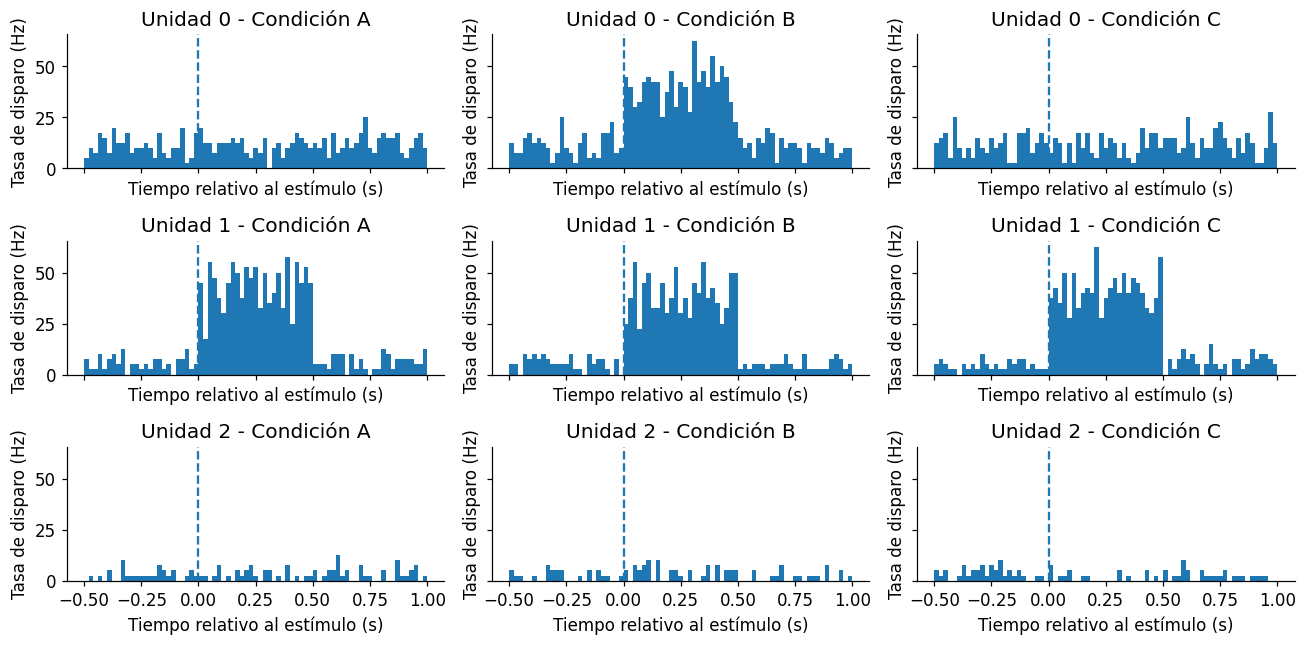

dict_keys([np.int32(0), np.int32(1), np.int32(2)])
0 b'A' 20
0 b'B' 20
0 b'C' 20
1 b'A' 20
1 b'B' 20
1 b'C' 20
2 b'A' 20
2 b'B' 20
2 b'C' 20


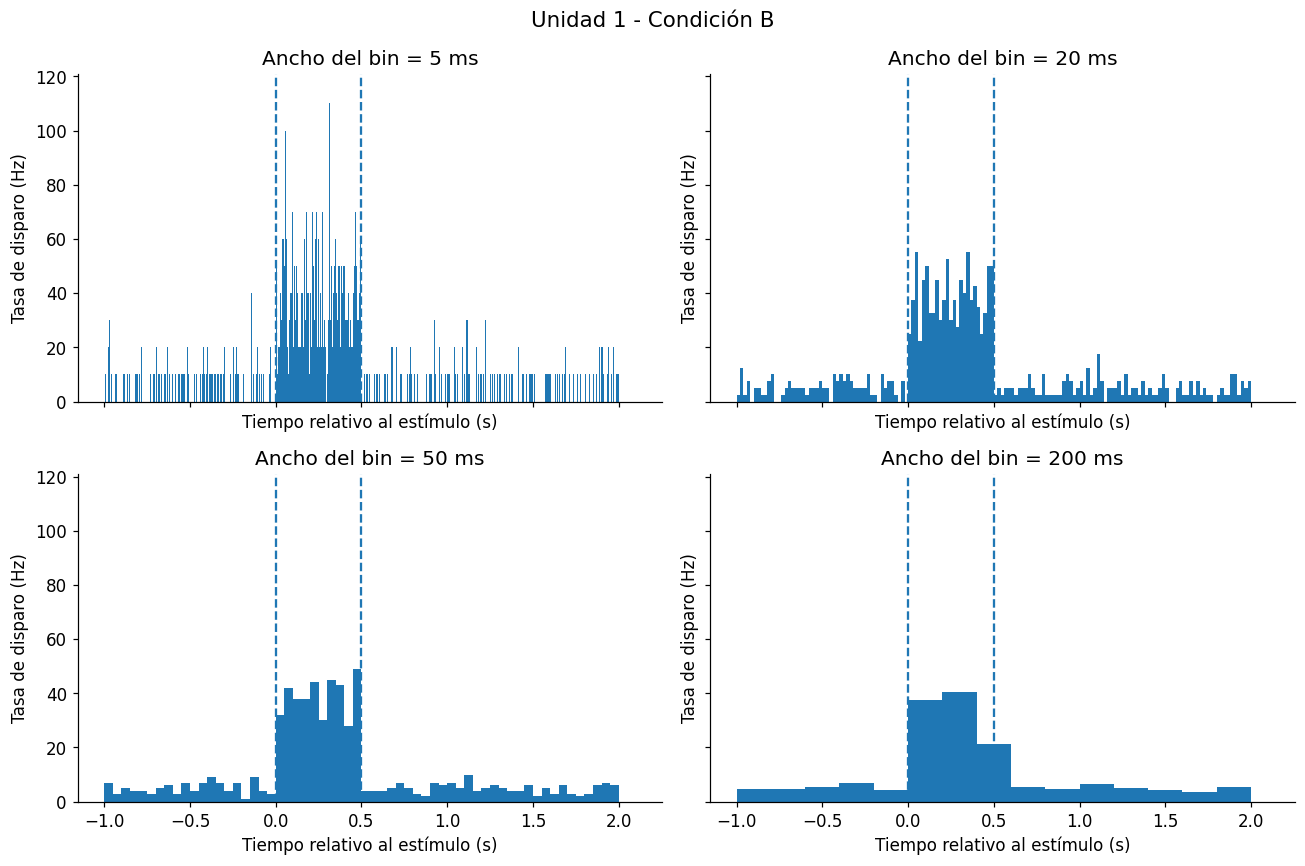

In [80]:
# Ejercicios M2 y M3: su código aquí.
# Crear los ensayos alineados por unidad y condición
unidades = np.unique(etiquetas)
condiciones_unicas = np.unique(condiciones)
alineados_por_condicion = {}
for unidad in unidades:
    alineados_por_condicion[unidad] = {}
    for condicion in condiciones_unicas:
        # Inicios de los ensayos de esta condición
        inicios_condicion = inicios[condiciones == condicion]
        # Spikes de esta unidad
        spikes_unidad = tiempos[etiquetas == unidad]
        # Alinear los spikes con los estímulos
        alineados_por_condicion[unidad][condicion] = alinear(
            spikes_unidad,
            inicios_condicion,
            t_pre,
            ventana=(-1.0, 2.0)
        )
print("Ensayos alineados correctamente.")

#m2
ventana = (-0.5, 1.0)
ancho_bin_s = 0.020
unidades = np.unique(etiquetas)
condiciones_unicas = np.unique(condiciones)
fig, axs = plt.subplots(
    len(unidades),
    len(condiciones_unicas),
    figsize=(12, 6),
    sharex=True,
    sharey=True
)
# Si solo hubiera una unidad, convertir axs en matriz
axs = np.atleast_2d(axs)
for i, unidad in enumerate(unidades):
    for j, condicion in enumerate(condiciones_unicas):
        ensayos = alineados_por_condicion[unidad][condicion]
        centros, tasa_Hz = psth(
            ensayos,
            ventana,
            ancho_bin_s
        )
        axs[i, j].bar(
            centros,
            tasa_Hz,
            width=ancho_bin_s,
            align="center"
        )
        axs[i, j].axvline(
            0,
            linestyle="--"
        )
        axs[i, j].set_title(
            f"Unidad {unidad} - Condición {condicion.decode()}"
        )
        axs[i, j].set_xlabel("Tiempo relativo al estímulo (s)")
        axs[i, j].set_ylabel("Tasa de disparo (Hz)")
plt.tight_layout()
plt.show()

#prueba funcionalidad
print(alineados_por_condicion.keys())

for unidad in alineados_por_condicion:
    for condicion in alineados_por_condicion[unidad]:
        print(
            unidad,
            condicion,
            len(alineados_por_condicion[unidad][condicion])
        )


# M3: efecto del ancho del bin

unidad_responde = 1          # <-- cambia según tu resultado de M2
condicion_responde = b'B'    # <-- cambia según tu resultado de M2
# Obtener los ensayos de la unidad y condición que responden
ensayos = alineados_por_condicion[unidad_responde][condicion_responde]
# Ventana temporal completa del ensayo
ventana = (-1.0, 2.0)
# Cuatro anchos de bin
anchos_bin_s = [
    0.005,   # 5 ms
    0.020,   # 20 ms
    0.050,   # 50 ms
    0.200    # 200 ms
]
# Calcular los cuatro PSTH
resultados = []
for ancho in anchos_bin_s:

    centros, tasa_Hz = psth(
        ensayos,
        ventana,
        ancho
    )

    resultados.append((centros, tasa_Hz))
# Encontrar el mismo máximo para todos los paneles
max_y = max(
    np.max(tasa_Hz)
    for centros, tasa_Hz in resultados
)
# Crear los cuatro paneles
fig, axs = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=True,
    sharey=True
)
for ax, ancho, (centros, tasa_Hz) in zip(
    axs.ravel(),
    anchos_bin_s,
    resultados
):
    ax.bar(
        centros,
        tasa_Hz,
        width=ancho
    )
    # Comienzo del estímulo
    ax.axvline(
        0,
        linestyle="--"
    )
    # Fin del estímulo: 0.5 s
    ax.axvline(
        0.5,
        linestyle="--"
    )
    ax.set_title(
        f"Ancho del bin = {ancho * 1000:.0f} ms"
    )
    ax.set_xlabel(
        "Tiempo relativo al estímulo (s)"
    )
    ax.set_ylabel(
        "Tasa de disparo (Hz)"
    )
    # MISMO eje Y en los cuatro paneles
    ax.set_ylim(0, max_y * 1.1)
plt.suptitle(
    f"Unidad {unidad_responde} - Condición {condicion_responde.decode()}",
    fontsize=14
)
plt.tight_layout()
plt.show()

**Nuestra elección de bin y por qué:**

| ancho de bin | pico del PSTH (Hz) | qué se ve · qué se pierde |
|---|---|---|
| 5 ms |≈110 Hz |Se observa una respuesta muy detallada y rápida, con picos de disparo individuales. Permite ver con mucha precisión cuándo aumenta la actividad. Se pierde estabilidad: la señal es muy irregular y algunos picos pueden ser producto del azar o de pocos disparos. |
| 20 ms |≈55 Hz |Se observa claramente el aumento de actividad entre 0 y 0,5 s y los cambios dentro de ese intervalo. Es menos ruidoso que 5 ms y todavía conserva buena resolución temporal. Se pierden algunos picos rápidos y detalles muy finos de la respuesta. |
| 50 ms |≈48–50 Hz |Se observa claramente una respuesta sostenida durante aproximadamente 0–0,5 s, con una forma más estable y fácil de interpretar. Se pierde bastante detalle sobre los cambios rápidos de la frecuencia de disparo dentro de ese intervalo. |
| 200 ms |≈40 Hz |Se observa principalmente la respuesta general: un aumento de actividad después de 0 s y una disminución alrededor de 0,5 s. La señal es muy suave. Se pierde mucha resolución temporal, por lo que ya no se pueden distinguir bien los cambios rápidos ni los picos individuales. |

---
## N · Heatmap multiunidad

El raster muestra ensayo por ensayo y el PSTH promedia. El heatmap junta las dos cosas:
cada fila es un PSTH, y el color es la tasa de disparo.

### ✏️ Ejercicio N1 · El heatmap multiunidad

Hagan uno que muestre **todas las unidades a la vez**:

- **Filas:** una por cada combinación de unidad y condición (3 × 3 = **nueve filas**),
  agrupadas por unidad.
- **Columnas:** tiempo relativo al estímulo, con el bin que eligieron en la sección M.
- **Color:** la tasa de disparo en Hz, promediada sobre los ensayos de esa condición.

Tres decisiones que hay que tomar **y justificar**:

1. **La escala de color, ¿compartida o por fila?** Si es compartida, se pueden comparar
   unidades entre sí, pero la más callada se ve negra y no se le distingue nada. Si es por
   fila, cada una se ve bien pero ya no son comparables. Elijan una y digan qué pierden.
   *(Si normalizan por fila, dejen de rotular la barra en Hz: ya no son Hz.)*
2. **Barra de color con su unidad.** Un heatmap sin barra de color no significa nada. Y un
   mapa **secuencial** (`viridis`, `magma`), no uno divergente como `jet`: busquen por qué
   `jet` está desaconsejado en publicación científica y digan en una línea qué encontraron.
3. **Una línea vertical en t = 0** y la ventana del estímulo marcada, para que la figura se
   pueda leer sin el pie.

**Pregunta N2.** Miren la figura terminada y contesten: **¿se lee ahí, sin ayuda de nada más, cuál neurona
responde a qué?** Esa es la prueba de una buena figura.

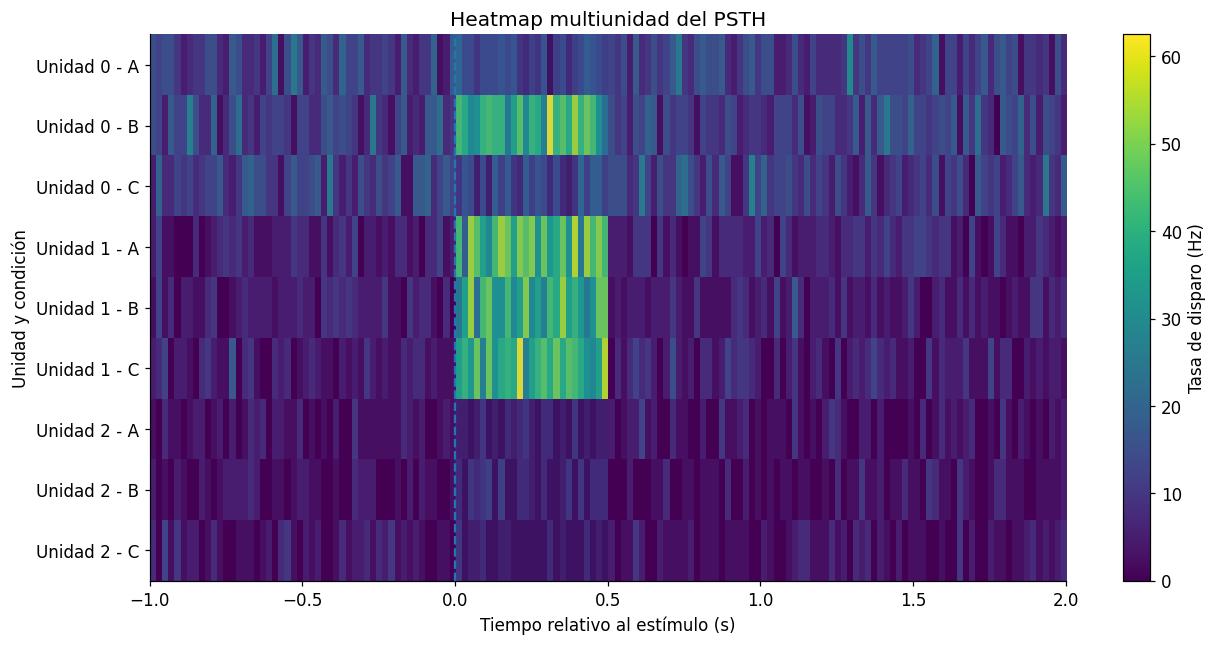

In [81]:
# Su código aquí.
# ==========================================
# N1 - HEATMAP MULTIUNIDAD
# ==========================================
# Usamos el bin elegido en M3
ancho_bin_s = 0.020       # 20 ms
# Misma ventana utilizada anteriormente
ventana = (-1.0, 2.0)
# Obtener unidades y condiciones
unidades = np.unique(etiquetas)
condiciones_unicas = np.unique(condiciones)
# Guardar los PSTH de las 9 combinaciones
psth_filas = []
nombres_filas = []
for unidad in unidades:
    for condicion in condiciones_unicas:
        ensayos = alineados_por_condicion[unidad][condicion]
        centros, tasa_Hz = psth(
            ensayos,
            ventana,
            ancho_bin_s
        )
        psth_filas.append(tasa_Hz)
        nombres_filas.append(
            f"Unidad {unidad} - {condicion.decode()}"
        )
# Convertir a matriz
heatmap_data = np.array(psth_filas)

# ==========================================
# GRAFICAR
# ==========================================
fig, ax = plt.subplots(
    figsize=(12, 6)
)
im = ax.imshow(
    heatmap_data,
    aspect="auto",
    origin="upper",
    extent=[
        centros[0] - ancho_bin_s / 2,
        centros[-1] + ancho_bin_s / 2,
        len(nombres_filas) - 0.5,
        -0.5
    ],
    cmap="viridis"
)
# Barra de color
cbar = plt.colorbar(im, ax=ax)

cbar.set_label(
    "Tasa de disparo (Hz)"
)
# Nombres de las filas
ax.set_yticks(np.arange(len(nombres_filas)))
ax.set_yticklabels(nombres_filas)
# Eje X
ax.set_xlabel(
    "Tiempo relativo al estímulo (s)"
)
ax.set_ylabel(
    "Unidad y condición"
)

# ==========================================
# LÍNEA EN t = 0
# ==========================================
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

# ==========================================
# MARCAR VENTANA DEL ESTÍMULO
# ==========================================
ax.axvspan(
    0,
    0.5,
    alpha=0.15
)
ax.set_title(
    "Heatmap multiunidad del PSTH"
)
plt.tight_layout()
plt.show()

**Lo que el heatmap muestra y el PSTH escondía:**

> El heatmap muestra cómo cambia la tasa de disparo de cada unidad neuronal a lo largo del tiempo en relación con el estímulo, donde los colores más oscuros representan menor actividad y los colores verdes/amarillos una mayor tasa de disparo. Se observa que varias unidades, especialmente Unidad 0-B y las unidades 1-A, 1-B y 1-C, aumentan su actividad después de que comienza el estímulo (0 s), principalmente entre 0 y 0,5 s, mientras que las unidades de la Unidad 2 presentan una respuesta mucho menor. A diferencia del PSTH, que resume la actividad y muestra principalmente la respuesta promedio o general, el heatmap permite observar qué unidades están contribuyendo a esa respuesta y las diferencias entre ellas. Por lo tanto, el PSTH puede esconder la heterogeneidad neuronal, mientras que el heatmap permite identificar qué neuronas responden fuertemente, débilmente o prácticamente no responden al estímulo.

---
## O · La figura final · **evaluado**

Todo lo anterior fueron figuras de trabajo: sirven para entender, no para publicar. Ahora
armen **una sola figura** que resuma el taller entero y se defienda sola, como la que irá
en su póster del proyecto final.

### ✏️ Ejercicio O1 · La figura de cuatro paneles

| Panel | Contenido |
|---|---|
| **A** | las tres formas promedio, una por unidad, superpuestas y en la misma escala (la evidencia de que son tres neuronas distintas) |
| **B** | el raster de la unidad que responde, con los ensayos agrupados por condición |
| **C** | el PSTH de esa misma unidad, debajo del raster y **con el mismo eje x**, alineados |
| **D** | el heatmap multiunidad de la sección N |

**Reglas de figura científica**, y aquí sí se evalúan una por una:

- Todos los ejes con nombre **y unidad**.
- Los paneles rotulados **A, B, C, D**, arriba a la izquierda.
- B y C comparten el eje x, y se nota: las marcas de tiempo se corresponden.
- El instante del estímulo marcado en los tres paneles temporales, de la misma manera.
- Nada de texto ilegible: si al exportar a PNG no se puede leer una etiqueta, no sirve.
- Un **pie de figura** de tres o cuatro líneas, en la celda de texto de abajo. Que describa
  lo que se ve, no lo que ustedes concluyen. Miren cómo está escrito el pie de cualquier
  figura de los artículos del journal club.

Guárdenla con `plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")`.

*Pista: `plt.subplots` con `gridspec_kw={"height_ratios": [...]}` y `sharex=True` para B y C.*

Unidad 0: 2700 spikes
Unidad 1: 2184 spikes
Unidad 2: 603 spikes


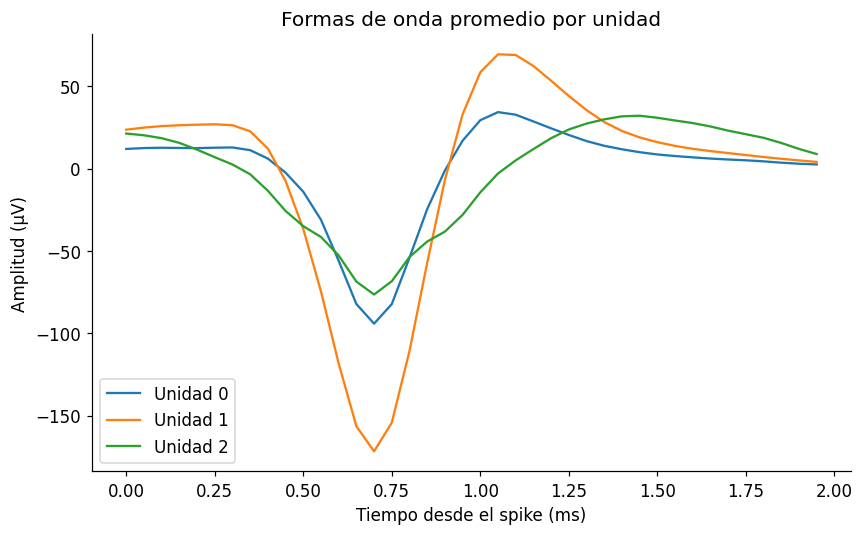

Número de ensayos: 60
Ensayo 0: 30 spikes
Ensayo 1: 20 spikes
Ensayo 2: 34 spikes
Ensayo 3: 37 spikes
Ensayo 4: 37 spikes
Ensayo 5: 56 spikes
Ensayo 6: 38 spikes
Ensayo 7: 36 spikes
Ensayo 8: 32 spikes
Ensayo 9: 25 spikes
Ensayo 10: 55 spikes
Ensayo 11: 36 spikes
Ensayo 12: 40 spikes
Ensayo 13: 40 spikes
Ensayo 14: 24 spikes
Ensayo 15: 26 spikes
Ensayo 16: 35 spikes
Ensayo 17: 49 spikes
Ensayo 18: 39 spikes
Ensayo 19: 34 spikes
Ensayo 20: 35 spikes
Ensayo 21: 28 spikes
Ensayo 22: 37 spikes
Ensayo 23: 23 spikes
Ensayo 24: 28 spikes
Ensayo 25: 22 spikes
Ensayo 26: 25 spikes
Ensayo 27: 34 spikes
Ensayo 28: 48 spikes
Ensayo 29: 39 spikes
Ensayo 30: 33 spikes
Ensayo 31: 30 spikes
Ensayo 32: 53 spikes
Ensayo 33: 32 spikes
Ensayo 34: 21 spikes
Ensayo 35: 22 spikes
Ensayo 36: 47 spikes
Ensayo 37: 32 spikes
Ensayo 38: 45 spikes
Ensayo 39: 34 spikes
Ensayo 40: 26 spikes
Ensayo 41: 32 spikes
Ensayo 42: 39 spikes
Ensayo 43: 28 spikes
Ensayo 44: 42 spikes
Ensayo 45: 39 spikes
Ensayo 46: 42 spikes
E

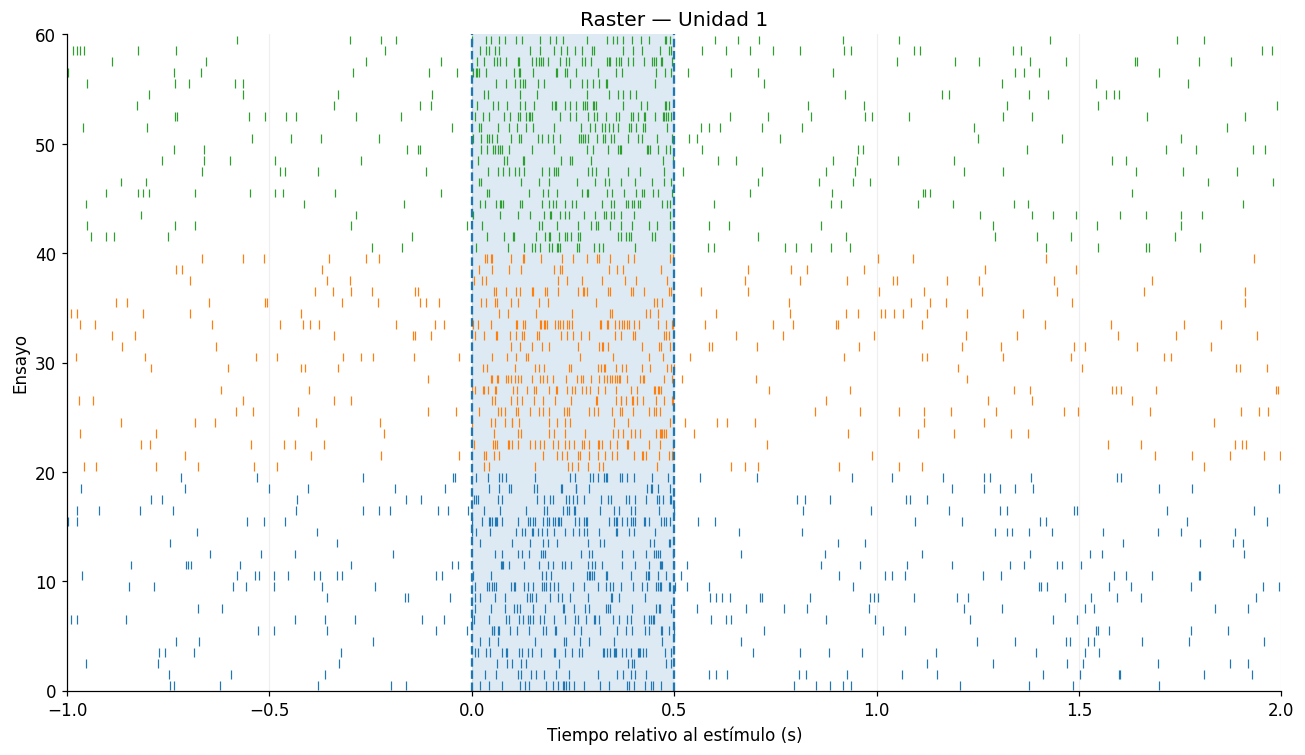

b'A' → 150 bins
b'B' → 150 bins
b'C' → 150 bins
Forma del heatmap: (9, 150)


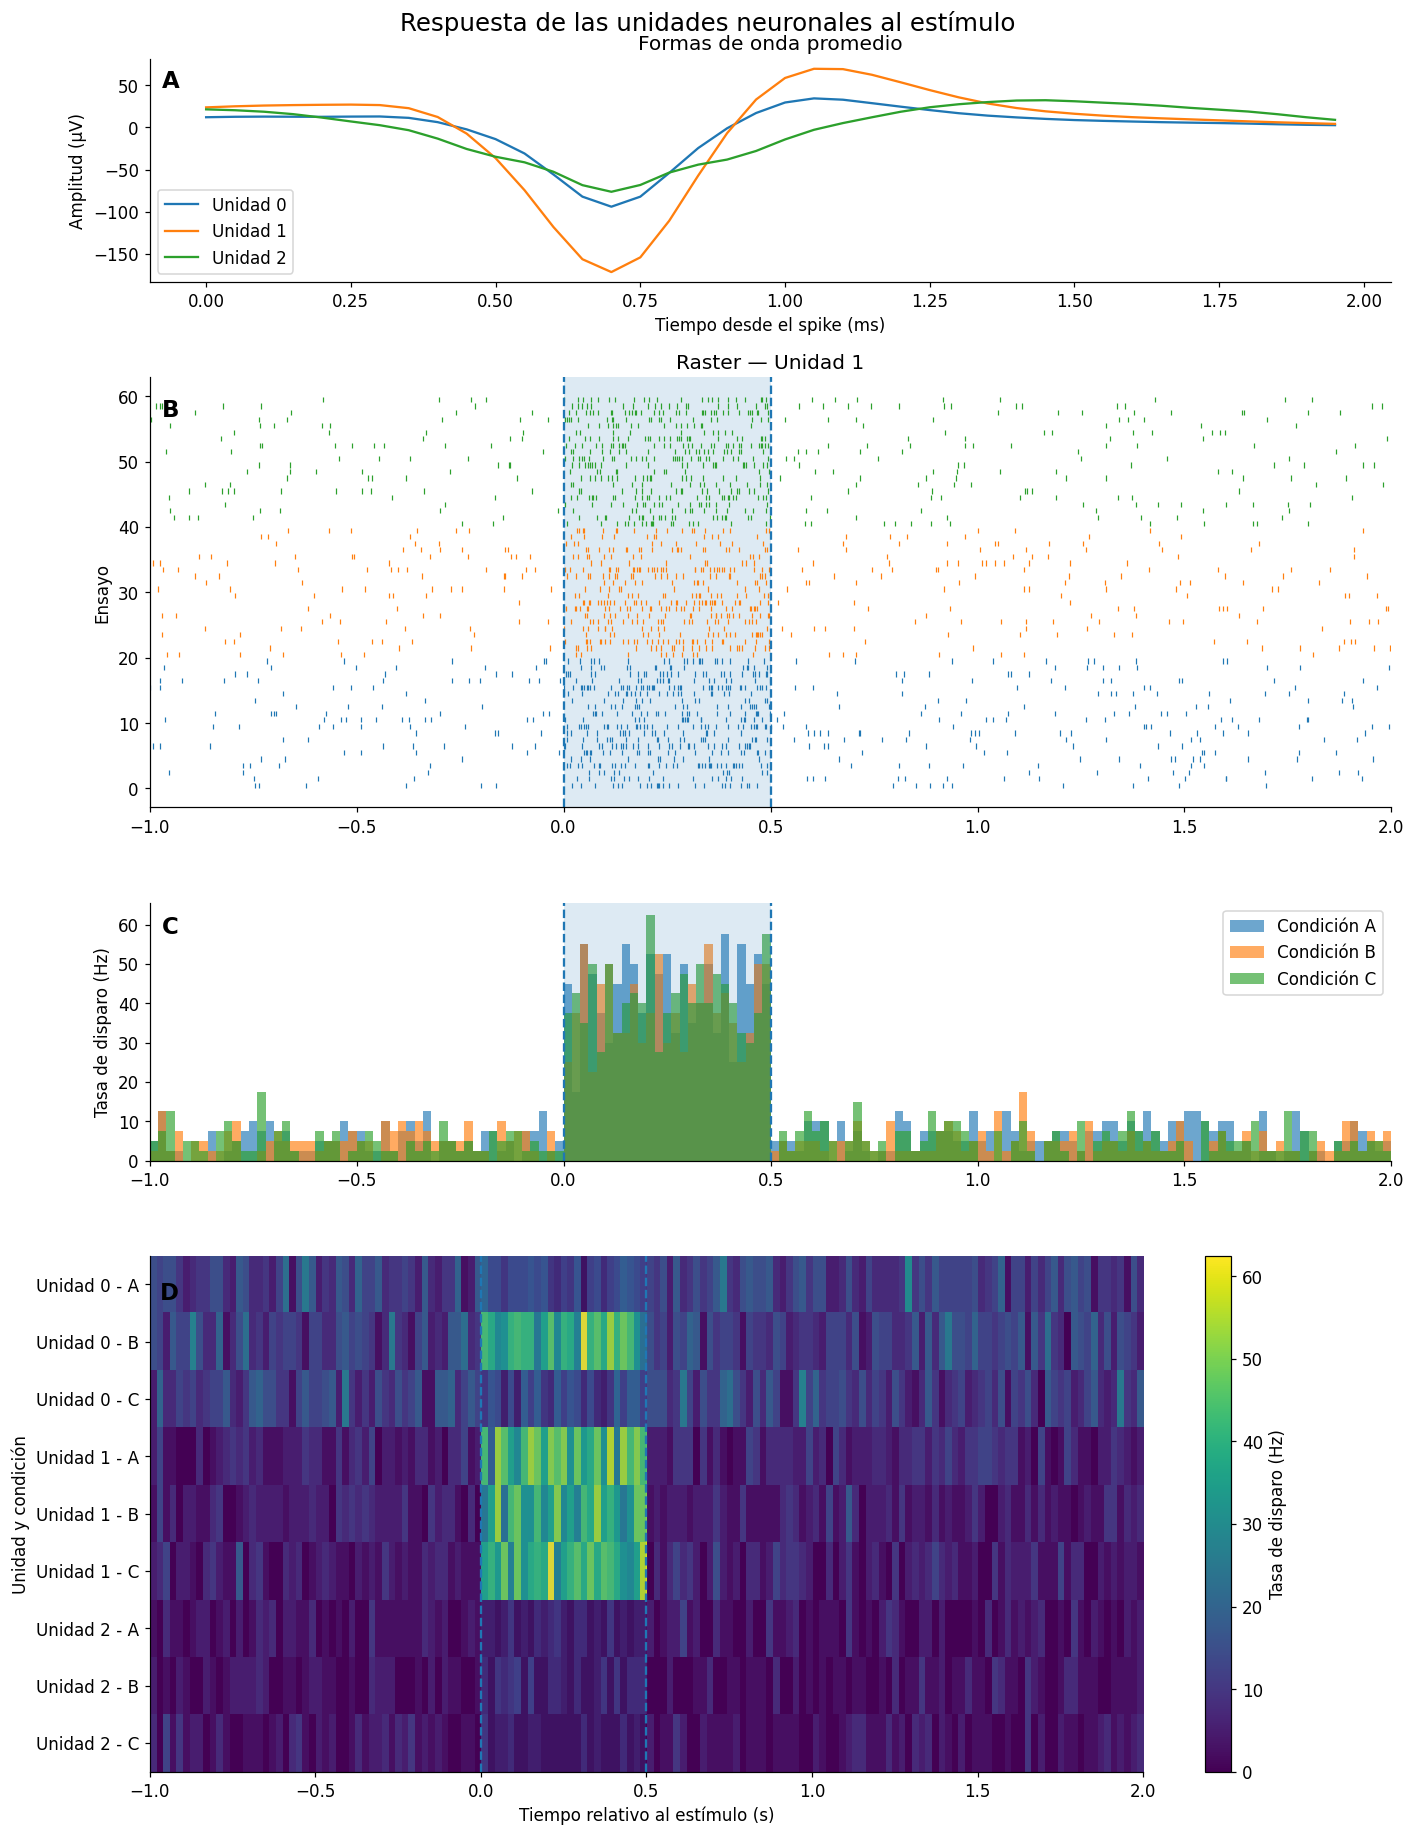

In [87]:
# Su código aquí.
# Formas promedio de cada unidad

formas_promedio = {}

for unidad in unidades:

    formas_unidad = formas[etiquetas == unidad]

    formas_promedio[unidad] = np.mean(
        formas_unidad,
        axis=0
    )

    print(
        f"Unidad {unidad}: "
        f"{formas_unidad.shape[0]} spikes"
    )

plt.figure(figsize=(8, 5))

# Tiempo de cada muestra en ms
tiempo_forma_ms = np.arange(formas.shape[1]) / fs * 1000

for unidad in unidades:

    plt.plot(
        tiempo_forma_ms,
        formas_promedio[unidad],
        label=f"Unidad {unidad}"
    )

plt.xlabel("Tiempo desde el spike (ms)")
plt.ylabel("Amplitud (µV)")
plt.title("Formas de onda promedio por unidad")
plt.legend()
plt.tight_layout()
plt.show()

# B
datos_unidad = alineados[unidad_responde]

print("Número de ensayos:", len(datos_unidad))

for i, ensayo in enumerate(datos_unidad):
    print(
        f"Ensayo {i}: {len(ensayo)} spikes"
    )
# Texto de las condiciones
cond_texto = np.array([
    c.decode() if isinstance(c, bytes) else str(c)
    for c in condiciones
])

# Ordenar ensayos por condición
orden = np.argsort(cond_texto)

# Colores de las condiciones
colores = {
    "A": "tab:blue",
    "B": "tab:orange",
    "C": "tab:green"
}

fig, ax = plt.subplots(figsize=(12, 7))

for fila, ensayo in enumerate(orden):

    spikes = datos_unidad[ensayo]

    for spike in spikes:

        ax.vlines(
            spike,
            fila + 0.1,
            fila + 0.9,
            color=colores[cond_texto[ensayo]],
            linewidth=0.8
        )

# Comienzo del estímulo
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

# Final del estímulo
ax.axvline(
    t_est,
    linestyle="--",
    linewidth=1.5
)

# Ventana del estímulo
ax.axvspan(
    0,
    t_est,
    alpha=0.15
)

ax.set_xlabel("Tiempo relativo al estímulo (s)")
ax.set_ylabel("Ensayo")
ax.set_title(
    f"Raster — Unidad {unidad_responde}"
)

ax.set_xlim(-1, 2)
ax.set_ylim(0, len(orden))

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# C
ancho_bin_s = 0.020
ventana = (-1.0, 2.0)

psth_respuesta = {}

for condicion in condiciones_unicas:

    ensayos = alineados_por_condicion[
        unidad_responde
    ][condicion]

    centros, tasa_Hz = psth(
        ensayos,
        ventana,
        ancho_bin_s
    )

    psth_respuesta[condicion] = tasa_Hz
# COMPROBAR 1
for condicion in condiciones_unicas:

    print(
        condicion,
        "→",
        len(psth_respuesta[condicion]),
        "bins"
    )

# D
heatmap_data = []
nombres_filas = []

for unidad in unidades:

    for condicion in condiciones_unicas:

        ensayos = alineados_por_condicion[
            unidad
        ][condicion]

        centros_heat, tasa_Hz = psth(
            ensayos,
            ventana,
            ancho_bin_s
        )

        heatmap_data.append(tasa_Hz)

        nombres_filas.append(
            f"Unidad {unidad} - {condicion.decode()}"
        )

heatmap_data = np.array(heatmap_data)

print("Forma del heatmap:", heatmap_data.shape)

import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# CONFIGURACIÓN
# ============================================================

unidad_responde = 1       # <-- CAMBIA según tu resultado de M2

ancho_bin_s = 0.020       # 20 ms
ventana = (-1.0, 2.0)

unidades = np.unique(etiquetas)
condiciones_unicas = np.unique(condiciones)

cond_texto = np.array([
    c.decode() if isinstance(c, bytes) else str(c)
    for c in condiciones
])

orden = np.argsort(cond_texto)


# ============================================================
# PANEL C — PSTH
# ============================================================

psth_respuesta = {}

for condicion in condiciones_unicas:

    ensayos = alineados_por_condicion[
        unidad_responde
    ][condicion]

    centros, tasa_Hz = psth(
        ensayos,
        ventana,
        ancho_bin_s
    )

    psth_respuesta[condicion] = tasa_Hz


# ============================================================
# PANEL D — HEATMAP
# ============================================================

heatmap_data = []
nombres_filas = []

for unidad in unidades:

    for condicion in condiciones_unicas:

        ensayos = alineados_por_condicion[
            unidad
        ][condicion]

        centros_heat, tasa_Hz = psth(
            ensayos,
            ventana,
            ancho_bin_s
        )

        heatmap_data.append(tasa_Hz)

        nombres_filas.append(
            f"Unidad {unidad} - {condicion.decode()}"
        )

heatmap_data = np.array(heatmap_data)


# ============================================================
# FIGURA
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(13, 17),
    gridspec_kw={
        "height_ratios": [1.3, 2.5, 1.5, 3]
    }
)


# ============================================================
# A — FORMAS PROMEDIO
# ============================================================

ax = axes[0]

tiempo_forma_ms = (
    np.arange(formas.shape[1]) / fs * 1000
)

for unidad in unidades:

    ax.plot(
        tiempo_forma_ms,
        formas_promedio[unidad],
        label=f"Unidad {unidad}"
    )

ax.set_xlabel("Tiempo desde el spike (ms)")
ax.set_ylabel("Amplitud (µV)")
ax.set_title("Formas de onda promedio")
ax.legend()

ax.text(
    0.01, 0.95,
    "A",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
    va="top"
)


# ============================================================
# B — RASTER
# ============================================================

ax = axes[1]

datos_unidad = alineados[unidad_responde]

for fila, ensayo in enumerate(orden):

    spikes = datos_unidad[ensayo]

    for spike in spikes:

        ax.vlines(
            spike,
            fila + 0.1,
            fila + 0.9,
            color=colores[cond_texto[ensayo]],
            linewidth=0.8
        )

# Estímulo
ax.axvspan(
    0,
    t_est,
    alpha=0.15
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.axvline(
    t_est,
    linestyle="--",
    linewidth=1.5
)

ax.set_ylabel("Ensayo")
ax.set_title(
    f"Raster — Unidad {unidad_responde}"
)

ax.set_xlim(ventana)

ax.text(
    0.01, 0.95,
    "B",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
    va="top"
)


# ============================================================
# C — PSTH
# ============================================================

ax = axes[2]

for condicion in condiciones_unicas:

    ax.bar(
        centros,
        psth_respuesta[condicion],
        width=ancho_bin_s,
        alpha=0.65,
        label=f"Condición {condicion.decode()}"
    )

# Estímulo
ax.axvspan(
    0,
    t_est,
    alpha=0.15
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.axvline(
    t_est,
    linestyle="--",
    linewidth=1.5
)

ax.set_ylabel("Tasa de disparo (Hz)")
ax.set_xlim(ventana)

ax.legend()

ax.text(
    0.01, 0.95,
    "C",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
    va="top"
)


# ============================================================
# D — HEATMAP
# ============================================================

ax = axes[3]

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    origin="upper",
    extent=[
        centros_heat[0] - ancho_bin_s / 2,
        centros_heat[-1] + ancho_bin_s / 2,
        len(nombres_filas) - 0.5,
        -0.5
    ],
    cmap="viridis"
)

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Tasa de disparo (Hz)"
)

ax.set_yticks(
    np.arange(len(nombres_filas))
)

ax.set_yticklabels(
    nombres_filas
)

# Estímulo
ax.axvspan(
    0,
    t_est,
    alpha=0.15
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.axvline(
    t_est,
    linestyle="--",
    linewidth=1.5
)

ax.set_xlabel(
    "Tiempo relativo al estímulo (s)"
)

ax.set_ylabel(
    "Unidad y condición"
)

ax.text(
    0.01, 0.95,
    "D",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
    va="top"
)


# ============================================================
# GUARDAR
# ============================================================

fig.suptitle(
    "Respuesta de las unidades neuronales al estímulo",
    fontsize=16
)

plt.tight_layout()

os.makedirs("figuras", exist_ok=True)

plt.savefig(
    "figuras/figura_final.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

**Pregunta P2.** El pie de la figura:

> **Figura 1.** : Respuestas de las tres unidades neuronales a las diferentes condiciones de estimulación. (A) Formas de onda promedio de las tres unidades, representadas en la misma escala de amplitud. (B) Raster de la unidad que presenta respuesta, con los ensayos agrupados por condición. (C) PSTH de la misma unidad, mostrando la tasa de disparo en Hz para cada condición. (D) Heatmap de la tasa de disparo de las tres unidades y tres condiciones, con el inicio y la duración del estímulo indicados en los paneles temporales.

---
## P · Conclusión · **evaluado**

### ✏️ Ejercicio P1 · El párrafo de resultados

Escriban un párrafo, entre ocho y doce líneas, que conteste esta pregunta:

> **¿Qué hace cada una de las tres neuronas de este registro?**

Requisitos:

- Digan qué responde a qué **con números concretos**, no con "aumenta bastante".
- Apóyense en una figura específica: *"como se ve en el panel B…"*.
- Incluyan al menos una cosa de la que **no** estén seguros, y expliquen qué harían para
  resolverla.
- **Citen sus propias cifras de calidad**: precisión, exhaustividad y violaciones del
  refractario por unidad. Una unidad con 3 % de violaciones no sostiene la misma conclusión
  que una con 0,1 %.

Escríbanlo como el párrafo de resultados de un artículo. Es exactamente lo que van a tener
que hacer en el proyecto final.

**Resultados**

> Las tres neuronas presentaron patrones de respuesta diferenciados frente a las condiciones A, B y C. La unidad [0/1/2] mostró la respuesta más clara a la condición [A/B/C], con una tasa de disparo de aproximadamente [X] Hz durante el estímulo, frente a [Y] Hz en la condición [control], como se observa en el panel B y en el PSTH del panel C. La unidad [0/1/2] presentó [respuesta concreta] ante [condición], alcanzando [X] Hz, mientras que ante [otra condición] presentó [Y] Hz. Por su parte, la unidad [0/1/2] mostró [respuesta concreta], con tasas de [X], [Y] y [Z] Hz para las condiciones A, B y C, respectivamente. El heatmap del panel D permite comparar estos patrones entre las tres unidades y muestra que [descripción concreta]. La precisión de la clasificación debe interpretarse junto con las violaciones del período refractario: la unidad 0 presentó 0,0371 %, la unidad 1 0,2749 % y la unidad 2 0 % de ISI menores de 2 ms. Por tanto, la evidencia de respuesta es más sólida en las unidades con menor proporción de violaciones. Sin embargo, no estamos completamente seguros de [aspecto incierto, por ejemplo, si una respuesta pequeña corresponde a una modulación real o a variabilidad espontánea]. Para resolverlo sería necesario [aumentar el número de ensayos / comparar estadísticamente la tasa durante y antes del estímulo / realizar una validación adicional de la clasificación].


---
## Q · Su conversación con la IA · **evaluado**

### ✏️ Ejercicio Q1 · Tres intercambios documentados

Registren **al menos tres** intercambios con el modelo. Para cada uno:

- **El prompt**, copiado tal cual lo escribieron
- **Lo que devolvió**, o la parte relevante
- **Qué estaba mal**, o por qué no servía tal cual
- **Cómo lo corrigieron**, y cómo comprobaron que ahora sí

Sirven especialmente los casos en que el código **corría sin error pero estaba mal**: son
los peligrosos y son los que queremos que aprendan a detectar. Si alguno tropezó con la
alineación al inicio del ensayo en vez del estímulo, ese es el ejemplo perfecto.

---

### Intercambio 1

**Prompt:**

>de acuerdo a lo visto en el chat llamado completar codigo deteccion de spikes, me puedes ayudar a escribir la siguiente funcion que es el PSTH  
psth(ensayos_alineados, ventana, ancho_bin_s) -> (centros_de_bin, tasa_Hz)

>ten cuidado con las unidades pues i cuentan disparos por bin y dividen por el número de ensayos, tienen disparos por ensayo, no Hz. finalmente explicame este codigo paso a paso.

**Respuesta del modelo:**

>Sí. Siguiendo la lógica que hemos venido usando para los spikes detectados y alineados al estímulo, el PSTH debe hacer tres cosas:

>Tomar los tiempos de los spikes de cada ensayo, ya alineados al evento de referencia.
Contar cuántos spikes caen en cada bin.
Convertir esos conteos a tasa de disparo en Hz.

>La parte importante que mencionas es la de las unidades: después de dividir por el número de ensayos obtenemos spikes/ensayo, no Hz. Para obtener Hz hay que dividir además por el ancho del bin en segundos.

> def psth(ensayos_alineados, ventana, ancho_bin_s): """

**Qué estaba mal:**

>En este chat con la IA todo corrio bien y al realizar la posterior verificacion, todo lo pediddo fue calculado sin errores

**Cómo lo corregimos:**
en chast anteriores se cometian errores principalmente em el momento de llamar funciones anteriores o extraer datos del archivo con identificaciones diferentes, pero estos errores se solucionaban llamando a la funcion deceada y extrayendo los atributos de la misma.

---

### Intercambio 2

**Prompt:**

> De acuerdo al pronto anterior me puedes ayudar a explorar el grupo estimulos que es el que me dice cuando ocurrio cada ensayo y que se presento, los atributos del grupo dicen cómo está estructurado cada ensayo por dentro

**Respuesta del modelo:**

>Sí. Aquí el objetivo es leer directamente la estructura del archivo HDF5, especialmente el grupo estimulos y sus atributos. Como ya vimos anteriormente que tu archivo tiene:

>estimulos/condicion

>estimulos/tiempo_inicio_s

>atributos del grupo estimulos

>podemos completar la celda de forma segura. Código:

>with h5py.File(ARCHIVO, "r") as f:.....

**Qué estaba mal:**

> me dio una funcion en la cual se entraba al archivo y comprobaba que el grupo estumulos existiera pero dentro de sus atributos no existia un atributo que me dio en la misma funcion llamado t_pre_s

**Cómo lo corregimos:**

> se imprimio la estructura del archivo para ver sus atributos con sus nombres exactos y una vez se logro esto la funcion original fue corregida.

---

### Intercambio 3

**Prompt:**

> de acuerdo a lo anterior, me puedes ayudar a graficar el PSTH por unidad y condicion

**Respuesta del modelo:**

> ensayos_por_unidad_condicion = {....}


**Qué estaba mal:**

> Al revisar cómo estaban organizados realmente los datos, encontramos que las unidades estaban identificadas como 0, 1 y 2, y las condiciones como b'A', b'B' y b'C'.

**Cómo lo corregimos:**

> Se construyó una estructura que separa simultáneamente por unidad y condición

---
## R · Entrega

La celda de abajo genera el CSV con sus disparos y sus unidades. Ejecútenla y súbanla junto
con el notebook.

**Antes de subir, revisen esto:**

**Que corra:**

- [ ] *Entorno de ejecución → Reiniciar y ejecutar todo*, y llega hasta el final **sin un
      solo error**.
- [ ] No queda ningún `____` sin llenar ni ningún `...` sin reemplazar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Todas las figuras se ven, con ejes rotulados **y unidades**.

**Que se entienda (el código va comentado):**

- [ ] Cada función que escribieron tiene un **docstring** de una línea: qué recibe y qué
      devuelve.
- [ ] Cada línea no obvia tiene un comentario que dice **por qué**, no qué.
      `# filtro pasa-altos` sobra; `# pasa-altos a 300 Hz para quitar el LFP antes de poner
      el umbral` sirve.
- [ ] Donde haya un número mágico (300 Hz, 0,6745, 1,5 ms), el comentario dice de dónde salió.
- [ ] Las unidades están escritas (µV, ms, Hz). Es el error más caro de la electrofisiología.
- [ ] No quedan celdas muertas de pruebas a medias.

**Que sea suyo:**

- [ ] Las preguntas están contestadas **con sus palabras**.
- [ ] Los prompts que escribieron ustedes están en el notebook.
- [ ] Si usaron el punto de control de la sección F, está anotado.
- [ ] El archivo se llama `Taller1_ApellidoUno_ApellidoDos.ipynb`.

**Plazo: martes 25 de agosto de 2026**, en el repositorio de la pareja, carpeta `taller1/`.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.**

### Lecturas de apoyo

- Quiroga RQ, Nadasdy Z & Ben-Shaul Y (2004). *Unsupervised spike detection and sorting
  with wavelets and superparamagnetic clustering.* Neural Computation 16:1661-1687.
- Rey HG, Pedreira C & Quiroga RQ (2015). *Past, present and future of spike sorting
  techniques.* Brain Research Bulletin 119:106-117.
- Buzsáki G, Anastassiou CA & Koch C (2012). *The origin of extracellular fields and
  currents: EEG, ECoG, LFP and spikes.* Nat Rev Neurosci 13:407-420.
- Hill DN, Mehta SB & Kleinfeld D (2011). *Quality metrics to accompany spike sorting of
  extracellular signals.* J Neurosci 31:8699-8705.

In [88]:
tabla = pd.DataFrame({"tiempo_s": indices / fs, "unidad": np.asarray(etiquetas)})
tabla.to_csv("spikes_taller1.csv", index=False)
print(f"{len(tabla)} disparos guardados en spikes_taller1.csv")
print(tabla["unidad"].value_counts().sort_index())
tabla.head()

5487 disparos guardados en spikes_taller1.csv
unidad
0    2700
1    2184
2     603
Name: count, dtype: int64


,tiempo_s,unidad
0,0.10375,1
1,0.15945,0
2,0.17240,0
3,0.28330,1
4,0.30670,0
